In [41]:
import sys
sys.path.insert(0, '.')
sys.path.insert(1, '..')
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure
from scipy.stats import exponweib
import seaborn as sns
from scipy.optimize import curve_fit
from utils import *
from scipy.stats import linregress

In [42]:
preds_dir = '../../preds/'
dataset_dir = '../../data/all_years_merged_era5.nc'

SCALING_FACTOR = 4
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'
years = [i for i in range(1984, 2024)]
print(years)

XYFONTSIZE = 16
LEGEND_TICK_FONTSIZE = 14

[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [43]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)
def get_psnr(predicted, ground_truth):
    """Calculate PSNR (Peak Signal-to-Noise Ratio) between predicted and ground truth."""
    # Find the maximum value in the ground truth data to use as the peak value
    if isinstance(predicted, torch.Tensor):
        predicted = predicted.numpy()
    
    max_value = np.max(ground_truth)  # Extract peak value dynamically
    mse = np.mean((predicted - ground_truth) ** 2)
    
    if mse == 0:
        return float('inf')  # Perfect match, infinite PSNR
    
    psnr = 20 * np.log10(max_value / np.sqrt(mse))
    return psnr


In [44]:
train_data = load_dataset(dataset_dir, TRAIN_START, TRAIN_END, 32)
num_samples = len(train_data.valid_time)
print(num_samples)
print(num_samples * 2)

4384
8768


In [45]:
files = os.listdir(preds_dir)
print(files)

['EDSR_20_23_2001_8x.pt', 'EDSR_ws_temp_2018_4x.pt', 'EDSR_ws_temp_2012_8x.pt', 'EDSR_ws_temp_2006_4x.pt', 'EDSR_20_23_1996_8x.pt', 'baseline_2016_4x.pt', 'baseline_2020_8x.pt', 'EDSR_ws_temp_2020_4x.pt', 'EDSR_random_2_2015_4x.pt', 'EDSR_ws_temp_2022_4x.pt', 'EDSR_ws_temp_1990_8x.pt', 'EDSR_20_23_2005_8x.pt', 'baseline_2002_4x.pt', 'EDSR_ws_temp_2000_8x.pt', 'EDSR_ws_temp_1986_8x.pt', 'EDSR_ws_temp_2009_8x.pt', 'EDSR_ws_temp_1989_4x.pt', 'EDSR_ws_temp_2016_8x.pt', 'EDSR_20_23_1985_8x.pt', 'baseline_1996_4x.pt', 'EDSR_ws_temp_2017_8x.pt', 'EDSR_random_4_2021_8x.pt', 'EDSR_20_23_1991_4x.pt', 'EDSR_20_23_2017_8x.pt', 'EDSR_ws_temp_1994_8x.pt', 'baseline_1994_8x.pt', 'EDSR_20_23_2023_4x.pt', 'baseline_2009_8x.pt', 'EDSR_ws_temp_2005_8x.pt', 'EDSR_ws_temp_1987_4x.pt', 'baseline_2009_2x.pt', 'EDSR_random_4_2017_8x.pt', 'EDSR_ws_temp_2018_8x.pt', 'EDSR_ws_temp_2021_4x.pt', 'EDSR_20_23_1983_4x.pt', 'baseline_1997_4x.pt', 'EDSR_random_1_2013_8x.pt', 'EDSR_ws_temp_2004_8x.pt', 'EDSR_2010_13_201

# Ground Truth

In [46]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)


# Low res input

In [47]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)


# Model Output

In [48]:
def is_leap_year(field):
    return field.shape[0] == 1464

In [49]:
def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
            
        #print("Current file: ", file)   
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)

            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            
        elif file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)

            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names


# Compare 


In [50]:
longitudes = eval_split.longitude.values[:32]
latitudes = eval_split.latitude.values[:32]
print(longitudes[0], longitudes[-1])    
print(latitudes[0], latitudes[-1])

6.45 14.2
55.16 47.41


1110


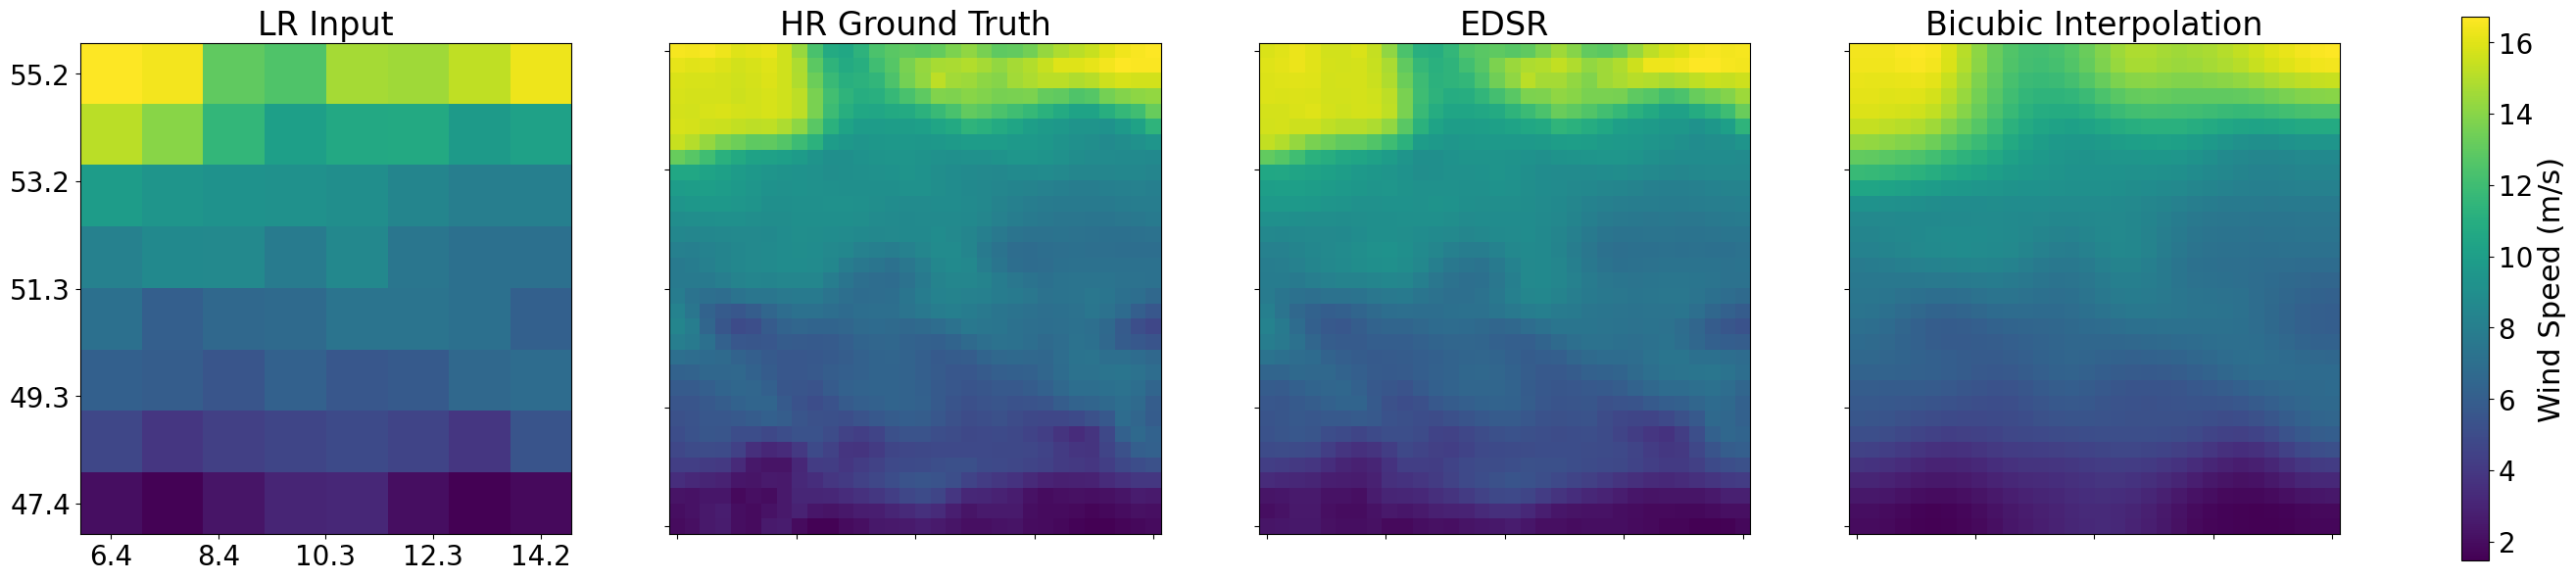

In [ ]:

def plot_comparison(fields, names, index):
    assert len(fields) == len(names)

    # Increase figure size for better readability
    fig, ax = plt.subplots(1, len(names), figsize=(len(names) * 8, len(names) * 6))

    fields = [field[index] for field in fields]
    long_ticks = np.linspace(longitudes[0], longitudes[-1], 5)
    lat_ticks = np.linspace(latitudes[0], latitudes[-1], 5)

    title_fontsize = 24
    axis_label_fontsize = 22
    tick_label_fontsize = 20
    colorbar_label_fontsize = 22
    colorbar_tick_fontsize = 20

    for i, field in enumerate(fields):
        im = ax[i].imshow(field, cmap='viridis')
        ax[i].set_title(names[i], fontsize=title_fontsize)

        ax[i].set_xticks(np.linspace(0, field.shape[1]-1, len(long_ticks)))
        ax[i].set_yticks(np.linspace(0, field.shape[0]-1, len(lat_ticks)))

        if i == 0:  
            ax[i].set_xticklabels([f'{round(i, 1)}' for i in long_ticks], fontsize=tick_label_fontsize)
            ax[i].set_yticklabels([f'{round(i, 1)}' for i in lat_ticks], fontsize=tick_label_fontsize)
        else: 
            ax[i].set_xticklabels([])
            ax[i].set_yticklabels([])

    # Colorbar with better font size
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.05, shrink=0.3)
    cbar.set_label('Wind Speed (m/s)', fontsize=colorbar_label_fontsize)

    for a in ax:
        a.tick_params(axis='both', labelsize=tick_label_fontsize)
    for ca in cbar.ax.yaxis.get_ticklabels():
        ca.set_fontsize(colorbar_tick_fontsize)
    plt.savefig(f'../../plots/comparison_{TEST_YEAR}.pdf', bbox_inches='tight') 

ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                        scaling_factor=SCALING_FACTOR, 
                                        year=TEST_YEAR, 
                                        normalization_scale=scale, 
                                        lr_ws=lr_wind_speeds, 
                                        gt_ws=ground_truth_wind_speeds)

index = np.random.randint(0, len(ground_truth_wind_speeds))
print(index)
plot_comparison(ws_fields, names, 0)


In [13]:
# plot u10, v10, t2m in low res and high res
def get_low_res_fields(test_data, scaling_factor):
    u10, v10, t2m = [], [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
        t2m.append(average_pooling(test_data['t2m'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    t2m = np.array(t2m)
    return u10, v10, t2m

lr_u10, lr_v10, lr_t2m = get_low_res_fields(eval_split, SCALING_FACTOR)
hr_u10 = eval_split['u10'].values
hr_v10 = eval_split['v10'].values
hr_t2m = eval_split['t2m'].values



741


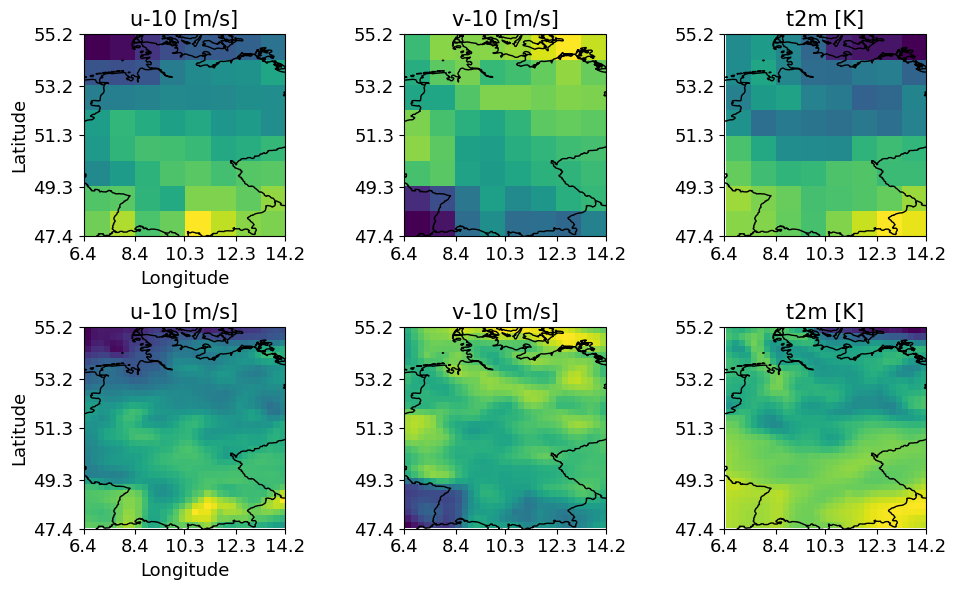

In [ ]:

idx = np.random.randint(0, len(eval_split.valid_time))
print(idx)

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(2, 3, figsize=(10, 6), subplot_kw={'projection': projection})

titles = ["u-10 [m/s]", "v-10 [m/s]", "t2m [K]"] 

lons = eval_split.longitude.values
lats = eval_split.latitude.values
long_ticks = np.linspace(lons[0], lons[-1], 5)
lat_ticks = np.linspace(lats[0], lats[-1], 5)
long_ticks = np.round(long_ticks, 1)
lat_ticks = np.round(lat_ticks, 1)

def plot_field(ax, data, title):
    font_size = 13
    ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=projection)
    
    im = ax.imshow(data, extent=[lons.min(), lons.max(), lats.min(), lats.max()], origin="lower", cmap="viridis")
    
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    
    ax.set_xticks(long_ticks, crs=projection)
    ax.set_yticks(lat_ticks, crs=projection)
    ax.tick_params(labelsize=10)
    if ax == axes[0, 0] or ax == axes[1, 0]:
        
        ax.set_xlabel("Longitude", fontsize=font_size)
        ax.set_ylabel("Latitude", fontsize=font_size)
    
    ax.set_title(title, fontsize=font_size+2)
    for a in ax.get_yticklabels():
        a.set_fontsize(font_size)
    for a in ax.get_xticklabels():
        a.set_fontsize(font_size)

    return im

im1 = plot_field(axes[0, 0], lr_u10[idx], f"{titles[0]}")
im2 = plot_field(axes[0, 1], lr_v10[idx], f"{titles[1]}")
im3 = plot_field(axes[0, 2], lr_t2m[idx], f"{titles[2]}")

im4 = plot_field(axes[1, 0], hr_u10[idx], f"{titles[0]}")
im5 = plot_field(axes[1, 1], hr_v10[idx], f"{titles[1]}")
im6 = plot_field(axes[1, 2], hr_t2m[idx], f"{titles[2]}")

plt.tight_layout()
plt.savefig(f'../../plots/fields_{TEST_YEAR}.pdf', bbox_inches='tight')


In [15]:
print(np.mean(ground_truth_wind_speeds))
print(np.std(ground_truth_wind_speeds))
print(np.min(ground_truth_wind_speeds))
print(np.max(ground_truth_wind_speeds))

3.7423608
2.4426157
0.0011898181
23.356188


In [ ]:
edsr, baseline = ws_fields[names.index("EDSR")], ws_fields[names.index("Bicubic Interpolation")]
mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
print(f"EDSR: MSE: {mse_edsr:.4f}, MAE: {mae_edsr:.4f}")
print(f"Baseline: MSE: {mse_baseline:.4f}, MAE: {mae_baseline:.4f}")


EDSR: MSE: 0.0540, MAE: 0.1612
Baseline: MSE: 0.1994, MAE: 0.3041


# Compare Metrics over years

In [17]:

ws_dict = {year: {} for year in years}
for year in years:
        eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)
        ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale, 
                                                lr_ws=lr_wind_speeds, 
                                                gt_ws=ground_truth_wind_speeds)
        
        edsr = ws_fields[names.index('EDSR')]
        baseline = ws_fields[names.index('Bicubic Interpolation')]
        ws_dict[year]['EDSR'] = edsr
        ws_dict[year]['Baseline'] = baseline
        ws_dict[year]['Ground Truth'] = ground_truth_wind_speeds


In [ ]:
def get_metrics_over_time(years):
    mses = {'EDSR': [], 'Bicubic': []}
    maes = {'EDSR': [], 'Bicubic': []}
   
    mse_skill_scores = []
    mae_skill_scores = []
    
    for year in years:
        edsr, baseline = ws_dict[year]['EDSR'], ws_dict[year]['Baseline']
        ground_truth_wind_speeds1 = ws_dict[year]['Ground Truth']
        
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds1)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds1)

        
        mse_skill_scores.append(get_skill_score(mse_edsr, mse_baseline))
        mae_skill_scores.append(get_skill_score(mae_edsr, mae_baseline))
        
        mses['EDSR'].append(mse_edsr)
        mses['Bicubic'].append(mse_baseline)
        maes['EDSR'].append(mae_edsr)
        maes['Bicubic'].append(mae_baseline)
       
        
    return mses, maes, mse_skill_scores, mae_skill_scores




def plot_metrics_over_time(years, mses, maes):
    n_models = len(mses)
    fig, ax = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))
    
    for i, model in enumerate(mses):
        ax[i, 0].plot(years, mses[model], 'o-', label=f"{model} - MSE", color='blue')
        ax[i, 0].set_title(f'{model} - MSE')
        ax[i, 0].set_xlabel('Year', fontsize=14)
        ax[i, 0].set_ylabel('MSE', fontsize = 14)
        ax[i, 0].legend(fontsize=12)
        ax[i, 0].grid(True)

        ax[i, 1].plot(years, maes[model], 'o-', label=f"{model} - MAE", color='orange')
        ax[i, 1].set_title(f'{model} - MAE')
        ax[i, 1].set_xlabel('Year')
        ax[i, 1].set_ylabel('MAE')
        ax[i, 1].legend()
        ax[i, 1].grid(True)

    plt.tight_layout()
    plt.show()
    
def plot_skill_scores(years, mse_ss, mae_ss):
    fig, ax = plt.subplots(2,1, figsize=(10,7))
    ax[0].plot(years, mse_ss, label='MSE Skill Score', color='darkgreen')
    ax[0].set_xlabel('Year', fontsize=14)
    ax[0].set_ylabel('Skill Score', fontsize=14)
    ax[0].legend(fontsize=12)
    #ax[0].grid(True)

    ax[1].plot(years, mae_ss, label='MAE Skill Score', color='darkgoldenrod')
    ax[1].set_xlabel('Year', fontsize=14)
    ax[1].set_ylabel('Skill Score', fontsize=14)
    ax[1].legend(fontsize=12)
    #ax[1].grid(True)

    for a in ax:
        a.tick_params(axis='both', labelsize=12)
    #plt.tight_layout()
    plt.savefig(f'../../plots/skill_scores.pdf', bbox_inches='tight')
    plt.show()
    

In [19]:

mses, maes, mse_skill_scores, mae_skill_scores = get_metrics_over_time(years)

Average decrease in MSE: 3.6306
Average decrease in MAE: 1.8556


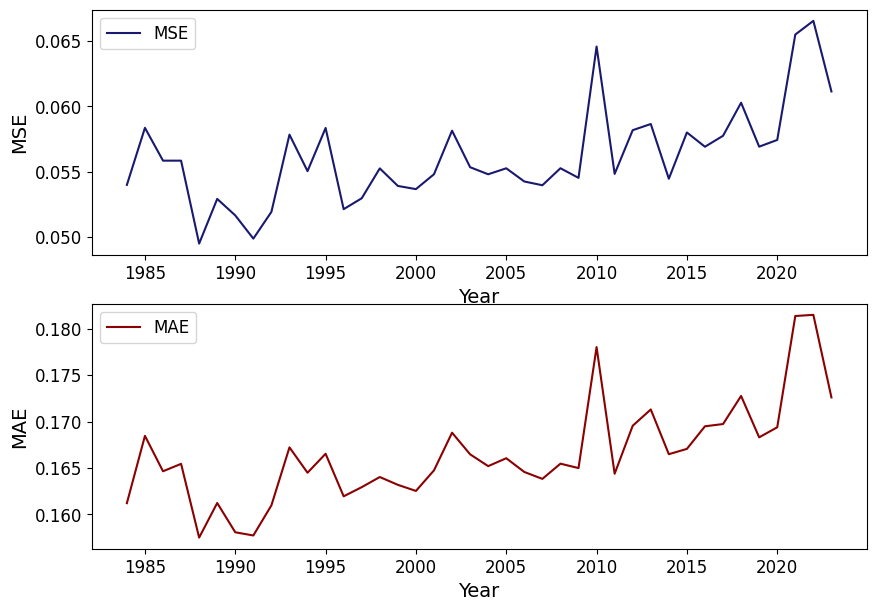

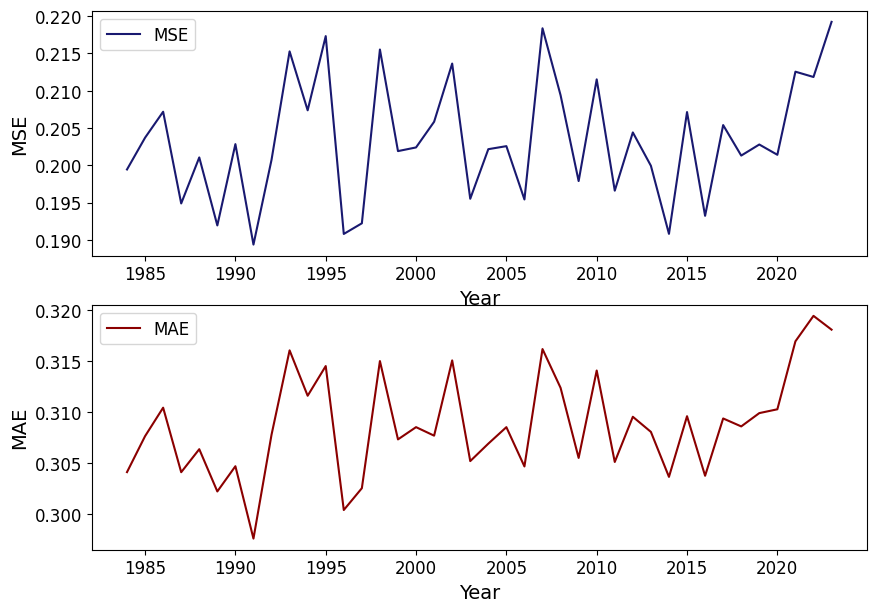

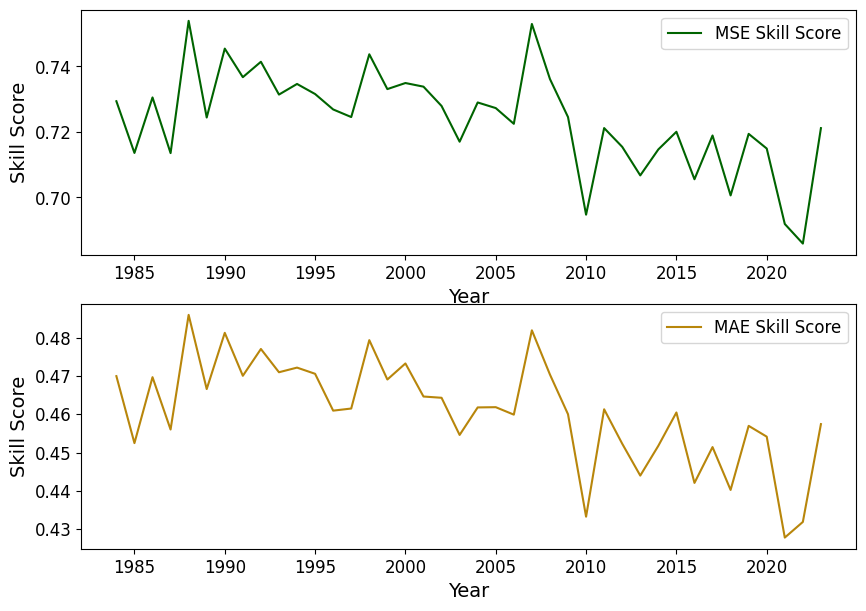

In [ ]:
def plot_metrics(years, mse, mae, model_name):
    fig, ax = plt.subplots(2,1, figsize=(10, 7))

    ax[0].plot(years, mse, label="MSE", color='midnightblue')
    ax[0].set_xlabel('Year', fontsize=14)
    ax[0].set_ylabel('MSE', fontsize=14)
    ax[0].legend(fontsize=12)
    #ax[0].grid(True)
    ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    # Plot MAE
    ax[1].plot(years, mae, label="MAE", color='darkred')
    ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    
    ax[1].set_xlabel('Year', fontsize=14)
    ax[1].set_ylabel('MAE', fontsize=14)
    ax[1].legend(fontsize=12)
    #ax[1].grid(True)

    for a in ax:
        a.tick_params(axis='both', labelsize=12)

    #plt.tight_layout()
    plt.savefig(f'../../plots/{model_name}_metrics.pdf', bbox_inches='tight')

plot_metrics(years, mses['EDSR'], maes['EDSR'], 'EDSR')

plot_metrics(years, mses['Bicubic'], maes['Bicubic'], 'Bicubic')

mse_decrease = np.mean([mses['Bicubic'][i] / mses['EDSR'][i] for i in range(len(years))])
mae_decrease = np.mean([maes['Bicubic'][i] / maes['EDSR'][i] for i in range(len(years))])
print(f"Average decrease in MSE: {mse_decrease:.4f}")
print(f"Average decrease in MAE: {mae_decrease:.4f}")
plot_skill_scores(years, mse_skill_scores, mae_skill_scores)

In [ ]:
error_images = {"bicubic" : [], "edsr" : [], "edsr_bias" : []}
top_percentile_error = {"bicubic" : [], "edsr" : []}
bias_per_year = {"bicubic" : [], "edsr" : [], "bicubic_90th": [], "edsr_90th": []}
mean_ws_per_pixel_per_year = []
for year in years:
        edsr = ws_dict[year]['EDSR']
        baseline = ws_dict[year]['Baseline']
        ground_truth_wind_speeds = ws_dict[year]['Ground Truth']

        edsr_error = np.abs(edsr - ground_truth_wind_speeds).mean(axis=0)
        baseline_error = np.abs(baseline - ground_truth_wind_speeds).mean(axis=0)
        
        bias_edsr = (edsr - ground_truth_wind_speeds).mean(axis=0)
        error_images["bicubic"].append(baseline_error)
        error_images["edsr"].append(edsr_error)
        error_images["edsr_bias"].append(bias_edsr)
        mask = np.where(ground_truth_wind_speeds >= np.percentile(ground_truth_wind_speeds, 90))
        
        top_percentile_error["bicubic"].append(np.abs(baseline - ground_truth_wind_speeds)[mask].mean())
        top_percentile_error["edsr"].append(np.abs(edsr - ground_truth_wind_speeds)[mask].mean())
        
        bias_per_year['bicubic'].append((baseline - ground_truth_wind_speeds).mean())
        bias_per_year['edsr'].append((edsr - ground_truth_wind_speeds).mean())
        bias_per_year['bicubic_90th'].append((baseline - ground_truth_wind_speeds)[mask].mean())
        bias_per_year['edsr_90th'].append((edsr - ground_truth_wind_speeds)[mask].mean())
        
        mean_ws_per_pixel_per_year.append(ground_truth_wind_speeds.mean(axis=0))

/tmp/ipykernel_30772/2264264894.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  edsr_error = np.abs(edsr - ground_truth_wind_speeds).mean(axis=0)
/tmp/ipykernel_30772/2264264894.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  baseline_error = np.abs(baseline - ground_truth_wind_speeds).mean(axis=0)
/tmp/ipykernel_30772/2264264894.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bias_edsr = (edsr - ground_truth_wind_speeds).mean(axis=0)
/tmp/ipykernel_30772/2264264894.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  top_percentile_error["bicubic"].append(np.abs(baseline - ground_truth_wind_speeds)[mask].mean

In [22]:
def get_stats_over_time(years):
    gt_statistics = {'mean': [], 'var': [], 'std' :[]}

    for year in years:
        _, gt_ws, _ = get_ground_truth_ws(data_dir=dataset_dir,
                                            train_start=TRAIN_START,
                                            train_end=TRAIN_END,
                                            test_year=year)
        gt_statistics['mean'].append(gt_ws.mean())
        gt_statistics['var'].append(gt_ws.var())
        gt_statistics['std'].append(gt_ws.std())
        
    return gt_statistics

gt_stats = get_stats_over_time(years)


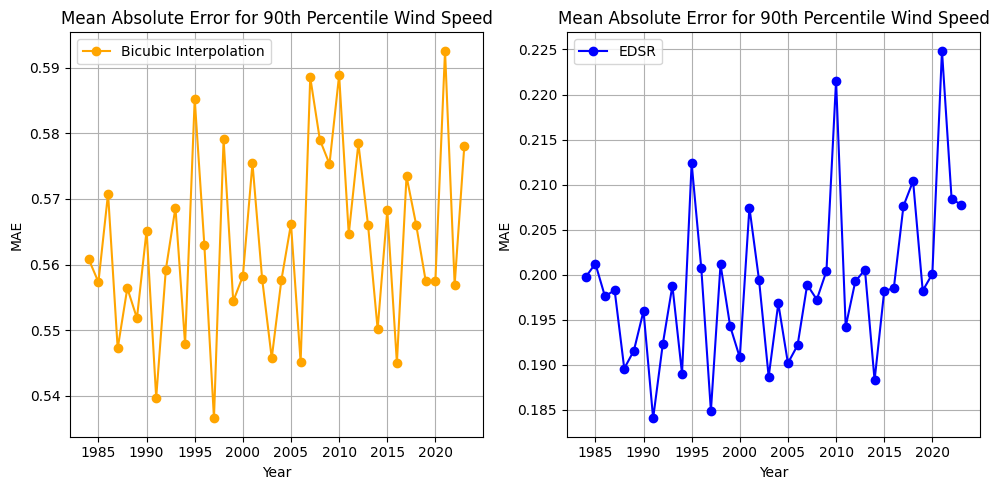

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(years, top_percentile_error["bicubic"], 'o-', label='Bicubic Interpolation', color='orange')
ax[0].set_title('Mean Absolute Error for 90th Percentile Wind Speed')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('MAE')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(years, top_percentile_error["edsr"], 'o-', label='EDSR', color='blue')
ax[1].set_title('Mean Absolute Error for 90th Percentile Wind Speed')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('MAE')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Correlation between wind speed field of 1984 and following years

In [24]:
reference_year_gt = ws_dict[1984]['Ground Truth'].mean(axis=0)
reference_year_edsr = ws_dict[1984]['EDSR'].mean(axis=0)
ssim_over_time = {"Ground Truth": [], "EDSR": []}   
pearson_over_time = {"Ground Truth": [], "EDSR": []}
spearman_over_time = {"Ground Truth": [], "EDSR": []}    
for year in years[1:]:
    current_year_gt = ws_dict[year]['Ground Truth'].mean(axis=0)
    current_year_edsr = ws_dict[year]['EDSR'].mean(axis=0)
    ssim_over_time["Ground Truth"].append(get_SSIM(current_year_gt, reference_year_gt))
    ssim_over_time["EDSR"].append(get_SSIM(current_year_edsr, reference_year_edsr))
    
    pearson_over_time["Ground Truth"].append(get_correlation(current_year_gt, reference_year_gt, method="pearson")[0])
    pearson_over_time["EDSR"].append(get_correlation(current_year_edsr, reference_year_gt, method="pearson")[0])    
    
    spearman_over_time["Ground Truth"].append(get_correlation(current_year_gt, reference_year_gt, method="spearman")[0])
    spearman_over_time["EDSR"].append(get_correlation(current_year_edsr, reference_year_gt, method="spearman")[0])

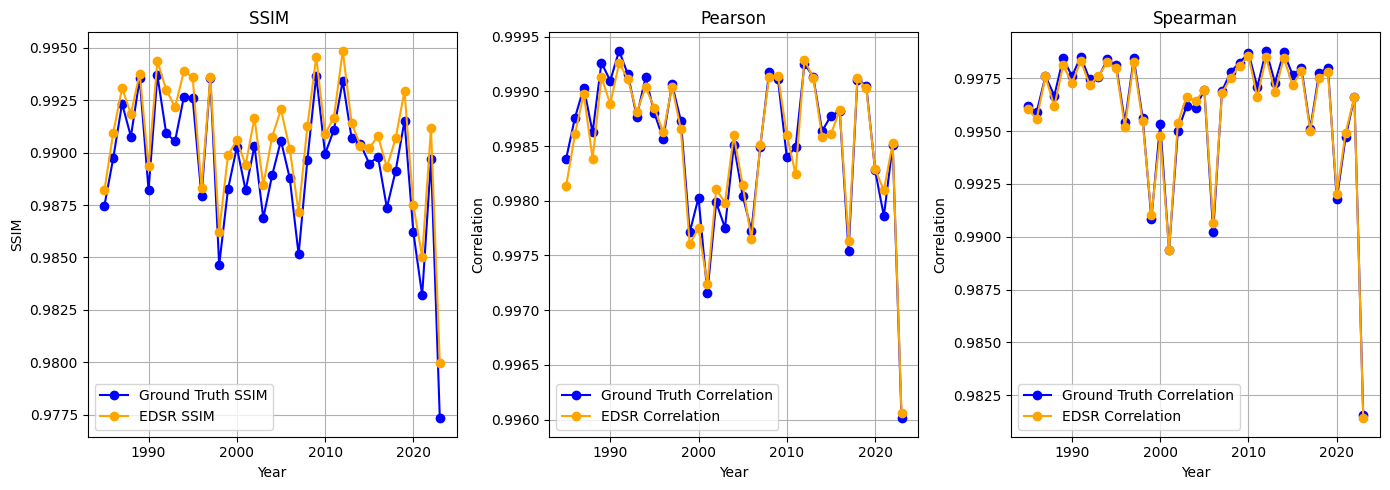

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 5))

ax[0].plot(years[1:], ssim_over_time["Ground Truth"], 'o-', label='Ground Truth SSIM', color='blue')
ax[0].plot(years[1:], ssim_over_time["EDSR"], 'o-', label='EDSR SSIM', color='orange')
ax[0].set_title('SSIM ')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('SSIM')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(years[1:], pearson_over_time["Ground Truth"], 'o-', label='Ground Truth Correlation', color='blue')
ax[1].plot(years[1:], pearson_over_time["EDSR"], 'o-', label='EDSR Correlation', color='orange')
ax[1].set_title('Pearson')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Correlation')
ax[1].legend()
ax[1].grid(True)
for year in years:
    ws_dict[year]["baseline"] = ws_dict[year]["Baseline"][1:-5]
    ws_dict[year]["Ground Truth"] = ws_dict[year]["Ground Truth"][1:-5]
"""

ax[2].plot(years[1:], spearman_over_time["Ground Truth"], 'o-', label='Ground Truth Correlation', color='blue')
ax[2].plot(years[1:], spearman_over_time["EDSR"], 'o-', label='EDSR Correlation', color='orange')
ax[2].set_title('Spearman')
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Correlation')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()

"""

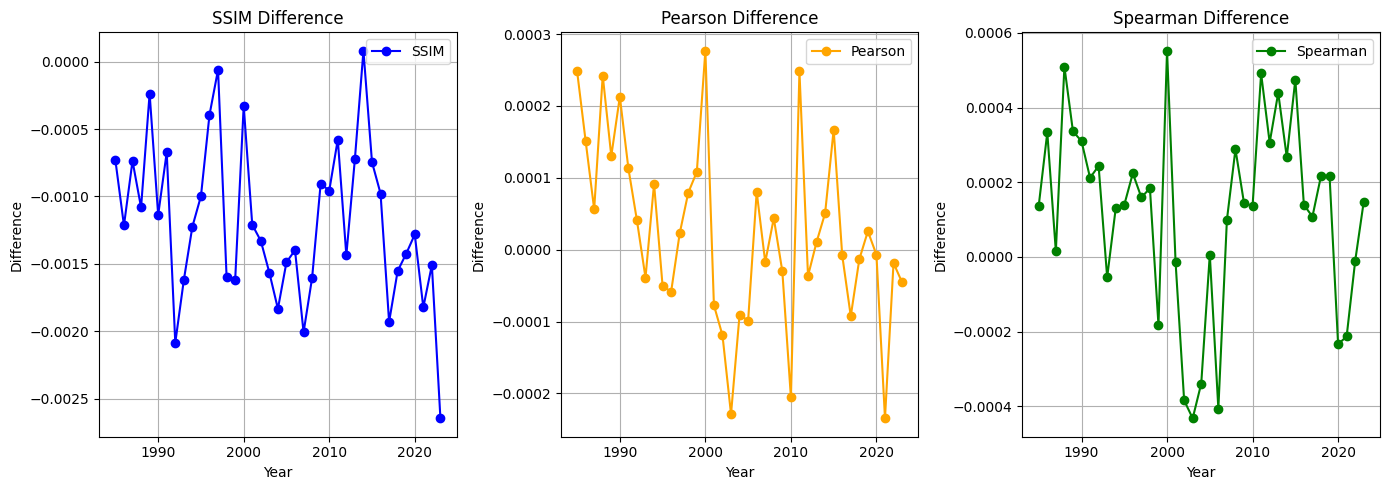

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 5))
diff_pearson = np.array(pearson_over_time["Ground Truth"]) - np.array(pearson_over_time["EDSR"])
diff_spearman = np.array(spearman_over_time["Ground Truth"]) - np.array(spearman_over_time["EDSR"])
diff_ssim = np.array(ssim_over_time["Ground Truth"]) - np.array(ssim_over_time["EDSR"])

ax[0].plot(years[1:], diff_ssim, 'o-', label='SSIM', color='blue')
ax[0].set_title('SSIM Difference')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Difference')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(years[1:], diff_pearson, 'o-', label='Pearson', color='orange')
ax[1].set_title('Pearson Difference')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Difference')
ax[1].legend()
ax[1].grid(True)

ax[2].plot(years[1:], diff_spearman, 'o-', label='Spearman', color='green')
ax[2].set_title('Spearman Difference')
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Difference')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()



# Error per pixel

In [27]:
interval = (2023-1984)//5
print(interval)
lons = eval_split.longitude.values
lats = eval_split.latitude.values
long_ticks = np.linspace(lons[0], lons[-1], 5)
lat_ticks = np.linspace(lats[0], lats[-1], 5)
long_ticks = np.round(long_ticks, 1)
lat_ticks = np.round(lat_ticks, 1)


7


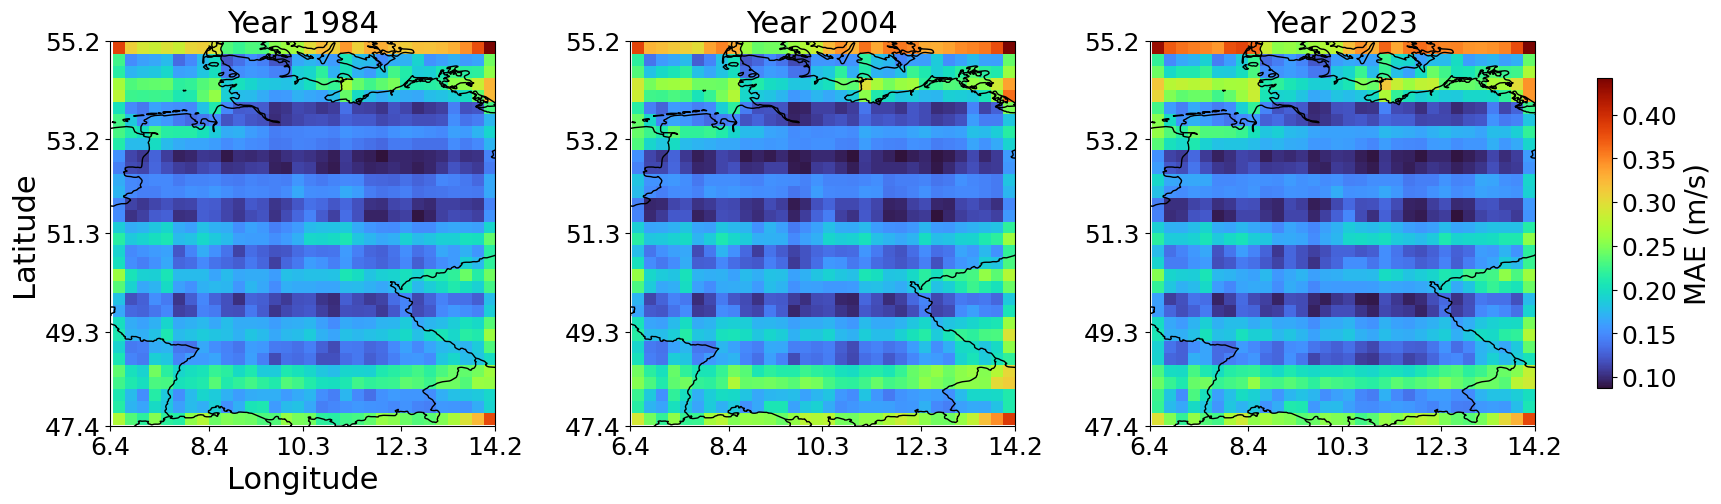

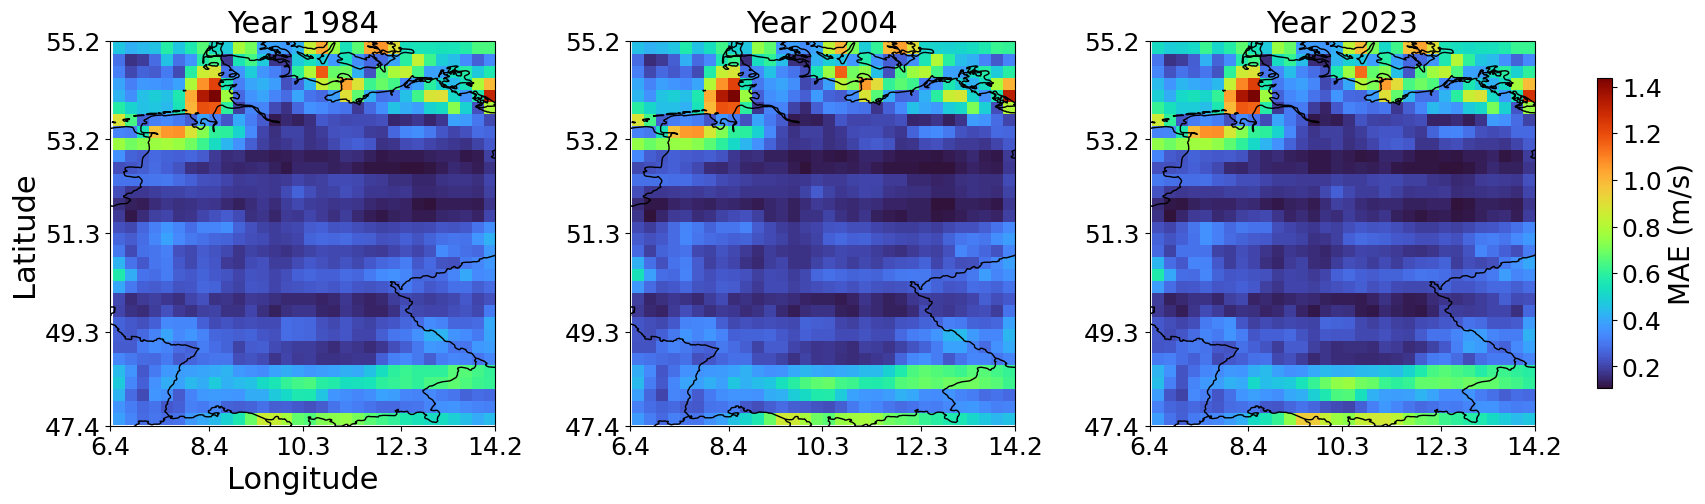

In [28]:


def plot_error_images(error_images, years, lons, lats, long_ticks, lat_ticks, edsr=True):
    projection = ccrs.PlateCarree()
    
    # Create subplots with Cartopy projection
    fig, ax = plt.subplots(1, 3, figsize=(20, 5), subplot_kw={'projection': projection})

    for i in range(3):
        ax[i].set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=projection)
        #

        img_idx = -1 if i == 2 else i * 20
        img = ax[i].imshow(error_images[img_idx], extent=[lons[0], lons[-1], lats[0], lats[-1]], 
                           origin='lower', cmap='turbo', transform=projection)

        ax[i].set_title(f"Year {years[img_idx]}", fontsize=22)

        ax[i].set_xticks(long_ticks, crs=projection)
        ax[i].set_yticks(lat_ticks, crs=projection)
        ax[i].tick_params(labelsize=10)
        if i == 0:
            ax[i].set_ylabel("Latitude", fontsize=22)
            ax[i].set_xlabel("Longitude", fontsize=22)
        
        ax[i].add_feature(cfeature.BORDERS, linewidth=1, edgecolor='black')
        ax[i].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
    # add colorbar
    cbar = fig.colorbar(img, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
    cbar.set_label('MAE (m/s)', fontsize=20)
    for a in ax:
        a.tick_params(axis='both', labelsize=18)
    for ca in cbar.ax.yaxis.get_ticklabels():
        ca.set_fontsize(18)
    #plt.tight_layout()
    name = 'EDSR' if edsr  else 'Bicubic'
    plt.savefig(f'../../plots/{name}_pixel_error.pdf', bbox_inches='tight')
    plt.show()

# Example usage (ensure you pass `lons`, `lats`, `long_ticks`, and `lat_ticks`)
plot_error_images(error_images["edsr"], years, lons, lats, long_ticks, lat_ticks)
plot_error_images(error_images["bicubic"], years, lons, lats, long_ticks, lat_ticks, edsr=False)


# Normalize Error per Pixel by Mean WS

/tmp/ipykernel_30772/3083107179.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalized_error_images["edsr"].append(error_images["edsr"][i] / mean_ws_per_pixel_per_year[i])
/tmp/ipykernel_30772/3083107179.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalized_error_images["bicubic"].append(error_images["bicubic"][i] / mean_ws_per_pixel_per_year[i])


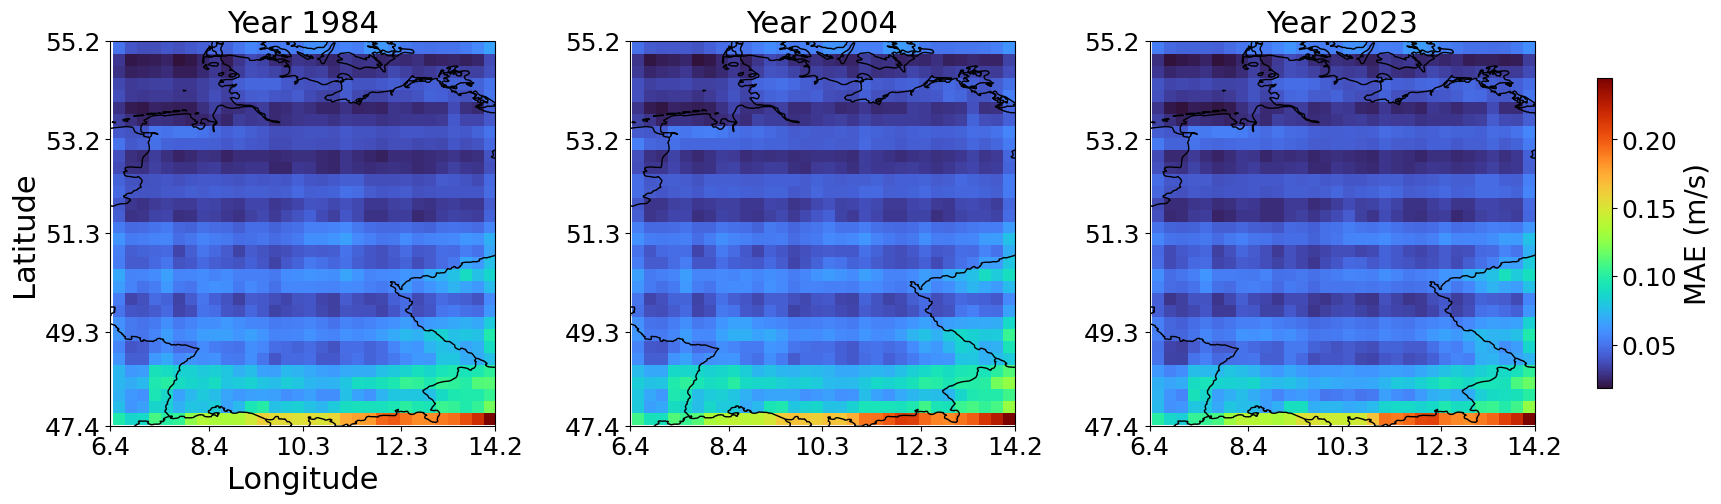

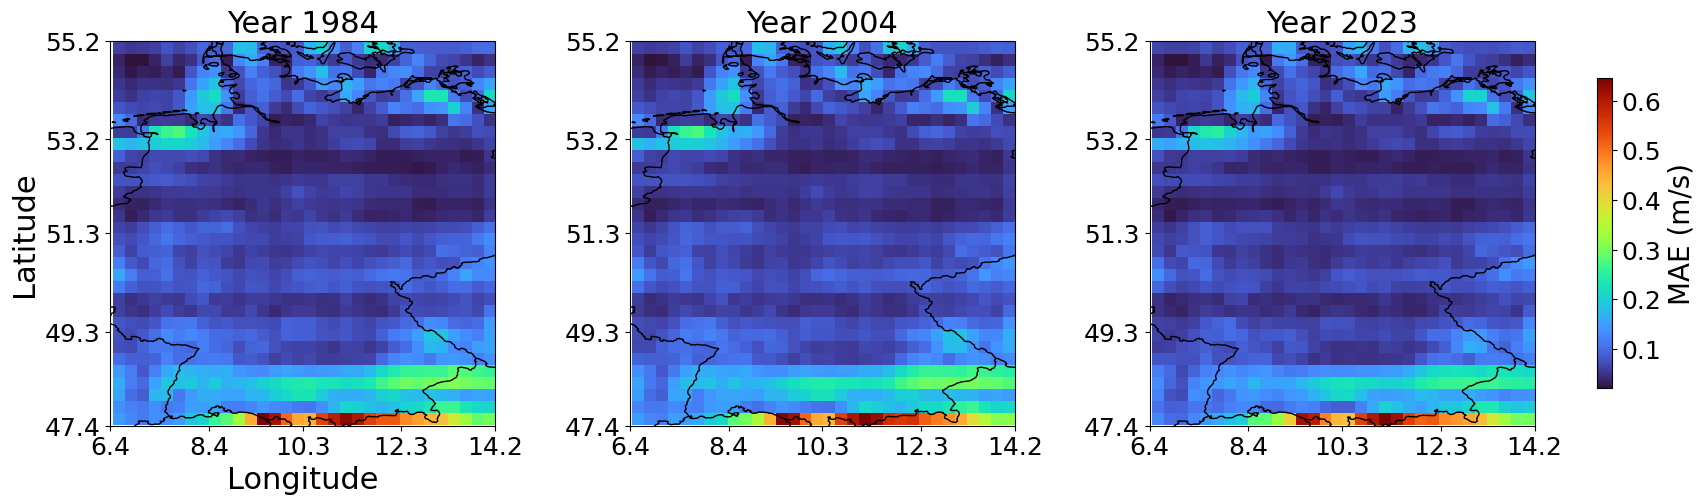

In [29]:
normalized_error_images = {"bicubic": [], "edsr": []}
for i in range(len(years)):
    normalized_error_images["edsr"].append(error_images["edsr"][i] / mean_ws_per_pixel_per_year[i])
    normalized_error_images["bicubic"].append(error_images["bicubic"][i] / mean_ws_per_pixel_per_year[i])

plot_error_images(normalized_error_images["edsr"], years, lons, lats, long_ticks, lat_ticks, edsr=True)
plot_error_images(normalized_error_images["bicubic"], years, lons, lats, long_ticks, lat_ticks, edsr=False)


# Bias per Pixel


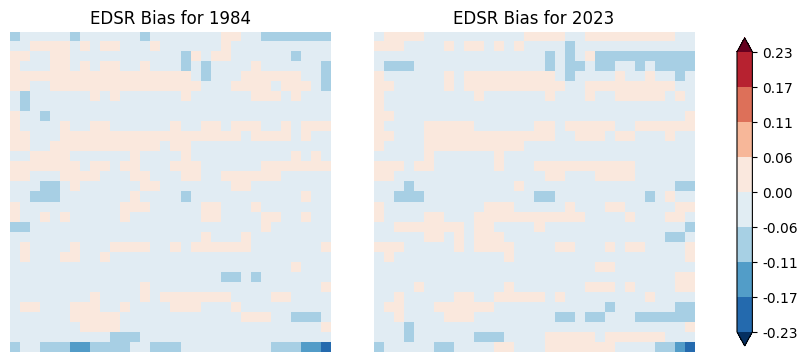

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

vmina, vmaxa = error_images["edsr_bias"][0].min(), error_images["edsr_bias"][0].max()
vminb, vmaxb = error_images["edsr_bias"][-1].min(), error_images["edsr_bias"][-1].max()

abs_max = max(abs(vmina), abs(vmaxa), abs(vminb), abs(vmaxb))
vmin, vmax = -abs_max, abs_max

levels = np.linspace(vmin, vmax, num=9)  

cmap = plt.cm.RdBu_r  
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')

fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

im1 = ax1.imshow(error_images["edsr_bias"][0], cmap=cmap, norm=norm)
ax1.set_title('EDSR Bias for 1984')
ax1.axis('off')

im2 = ax2.imshow(error_images["edsr_bias"][-1], cmap=cmap, norm=norm)
ax2.set_title('EDSR Bias for 2023')
ax2.axis('off')

cbar = fig.colorbar(im2, ax=[ax1, ax2], orientation='vertical', ticks=levels, shrink=0.8)
cbar.ax.set_yticklabels([f'{lvl:.2f}' for lvl in levels])

plt.show()


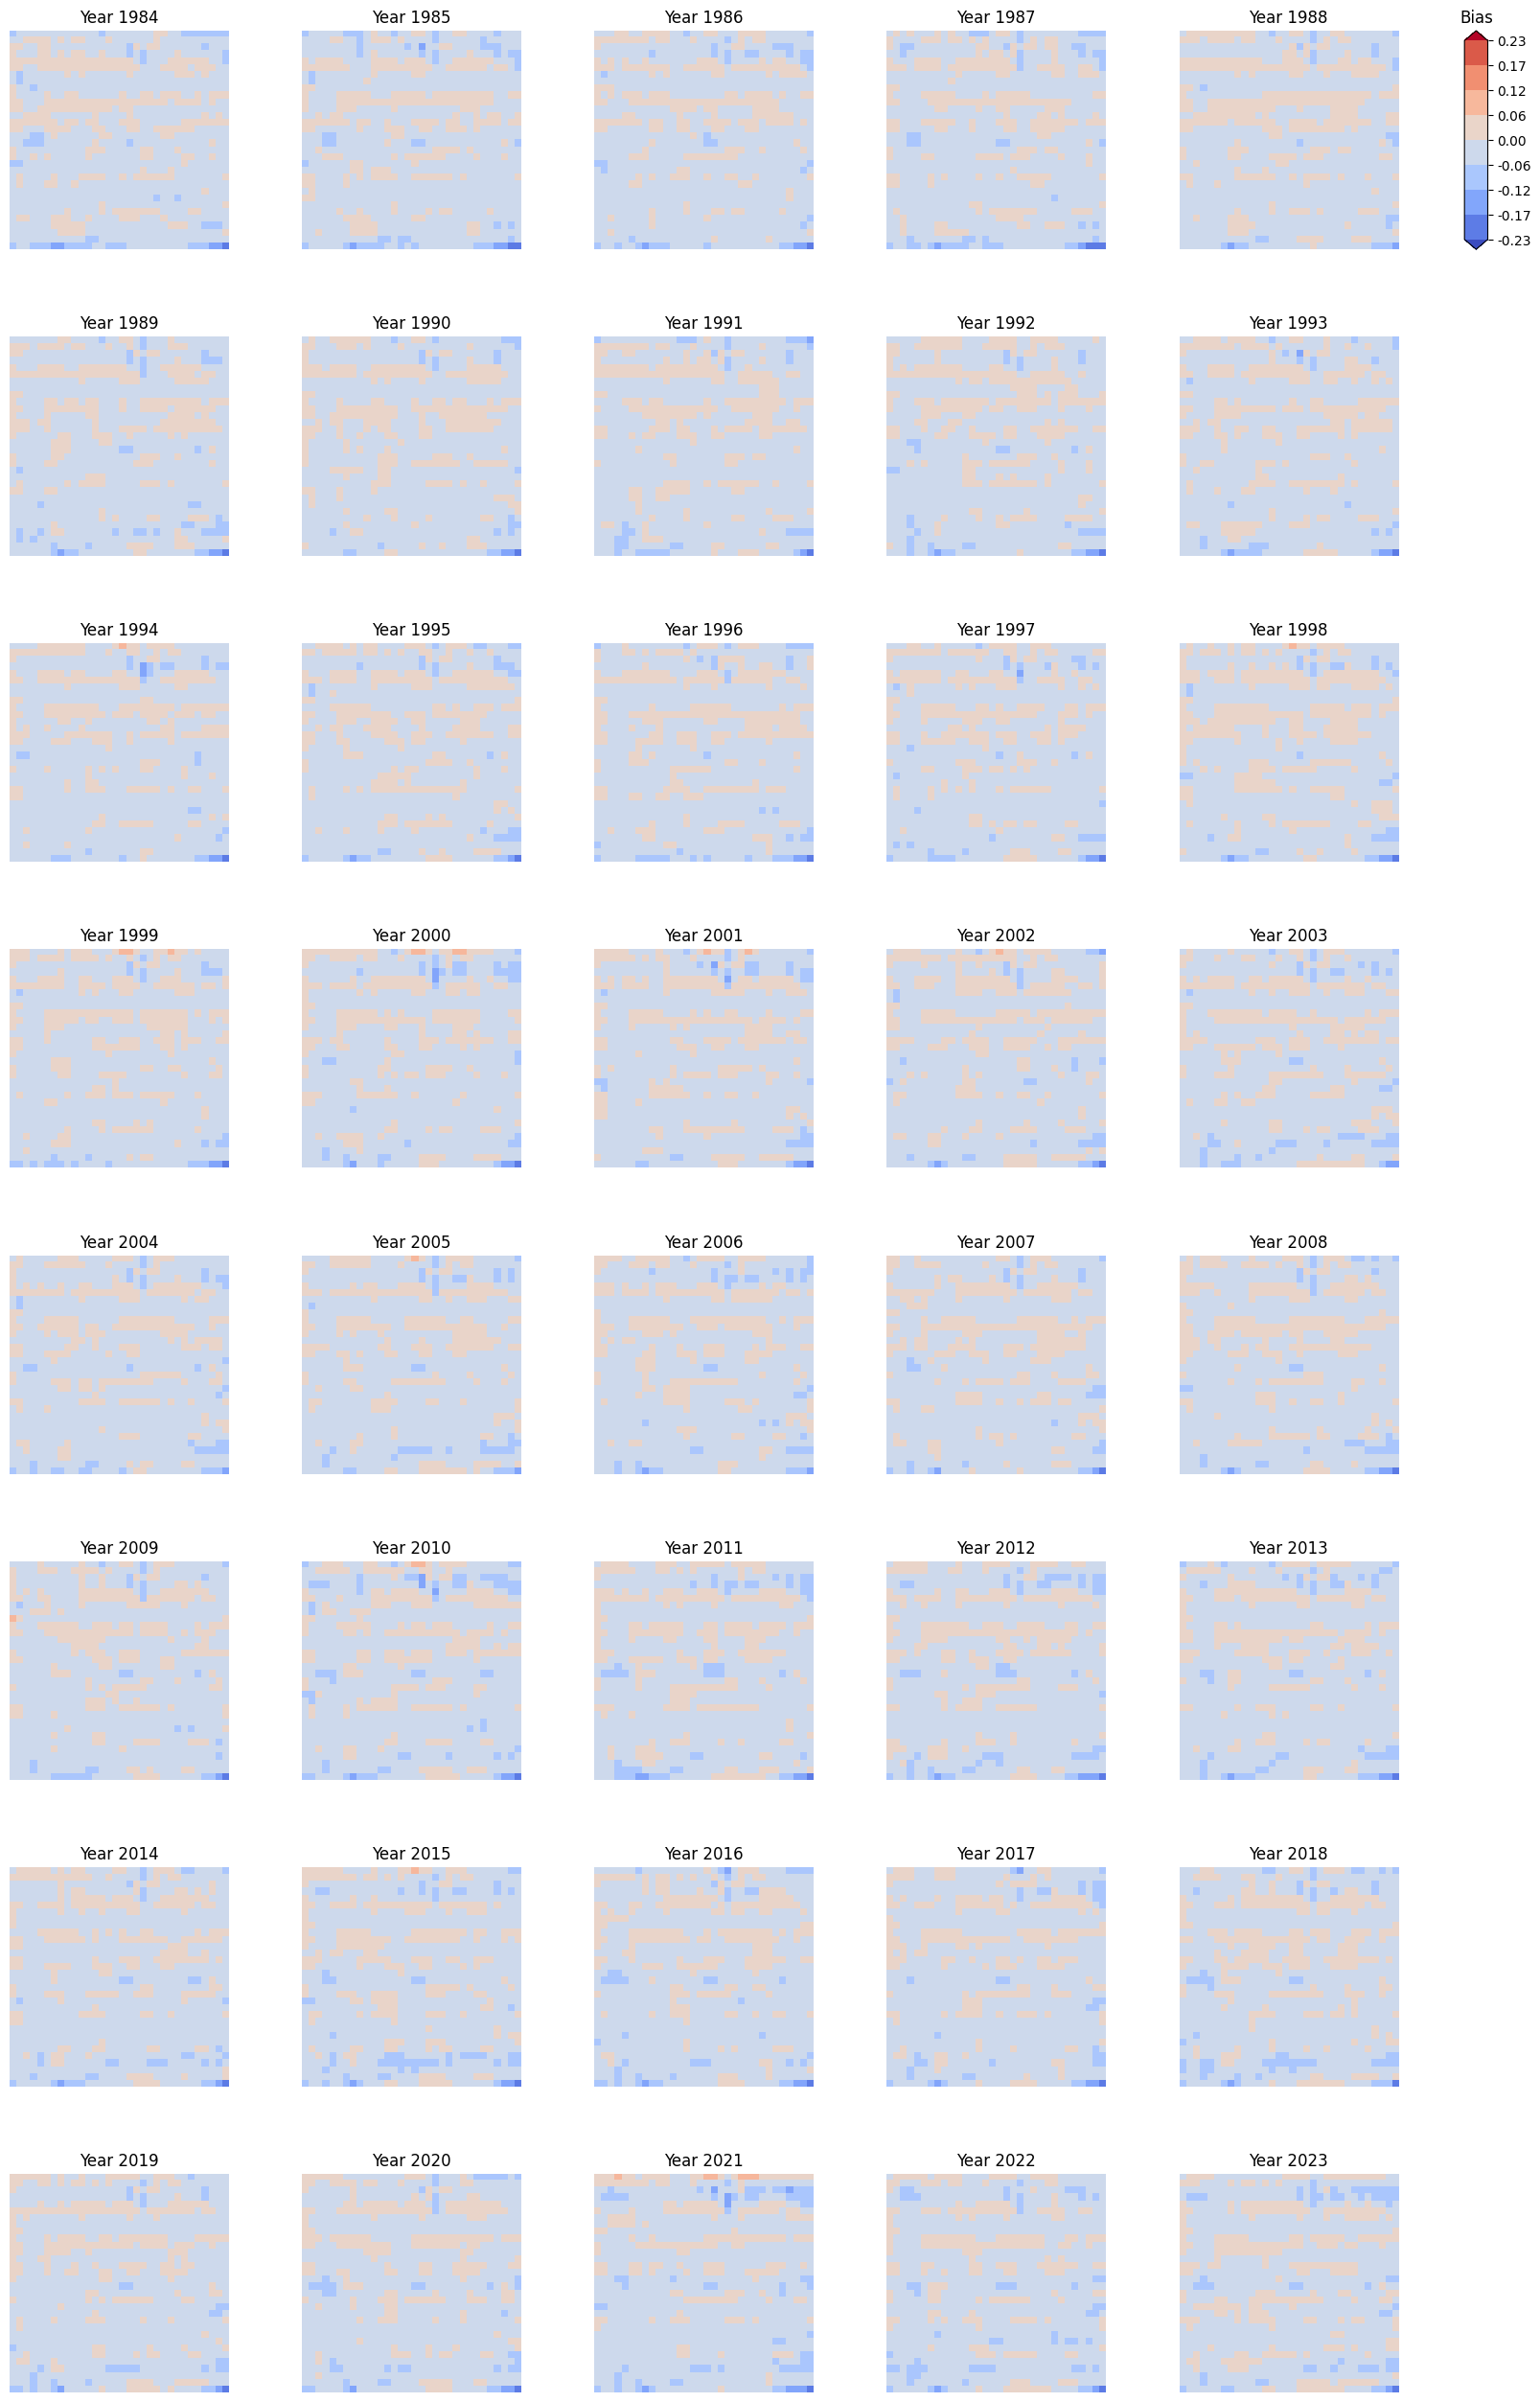

In [31]:
error_images["edsr_bias"] = np.array(error_images["edsr_bias"])

vmina = error_images["edsr_bias"].min()
vmaxa = error_images["edsr_bias"].max()
abs_max = max(abs(vmina), abs(vmaxa))
vmin, vmax = -abs_max, abs_max

levels = np.linspace(vmin, vmax, num=9)  
cmap = plt.cm.coolwarm  
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')

num_years = error_images["edsr_bias"].shape[0]

ncols = 5
nrows = int(np.ceil(num_years / ncols))

fig = plt.figure(figsize=(4 * ncols, 4 * nrows))  
gs = fig.add_gridspec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.1], wspace=0.3, hspace=0.4)

for i in range(num_years):
    ax = fig.add_subplot(gs[i // ncols, i % ncols])
    im = ax.imshow(error_images["edsr_bias"][i], cmap=cmap, norm=norm)
    ax.set_title(f'Year {1984 + i}')  
    ax.axis('off')

last_row_index = nrows - 1
last_col_index = (num_years - 1) % ncols  

cbar_ax = fig.add_subplot(gs[0, -1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', ticks=levels, shrink=0.8)
cbar.ax.set_yticklabels([f'{lvl:.2f}' for lvl in levels])
cbar_ax.set_title('Bias', fontsize=12)

plt.show()


# Cumulative Bias from 1984 to 2023


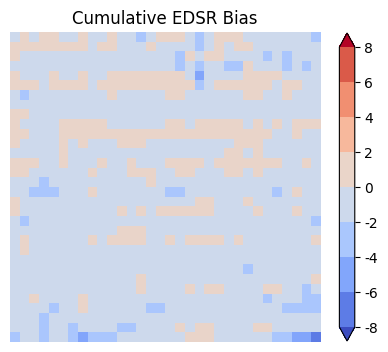

In [32]:
cum_bias_image = np.array(error_images["edsr_bias"]).sum(axis=0)
cbar_min = cum_bias_image.min()
cbar_max = cum_bias_image.max()
abs_max = max(abs(cbar_min), abs(cbar_max))
vmin, vmax = -abs_max, abs_max
cmap = plt.cm.coolwarm
levels = np.linspace(vmin, vmax, num=9)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')
fig, ax = plt.subplots(1, 1, figsize=(5,5))
im = ax.imshow(cum_bias_image, cmap=cmap, norm=norm)
ax.set_title('Cumulative EDSR Bias')
ax.axis('off')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.set_yticklabels([f'{lvl:.0f}' for lvl in levels])

plt.show()

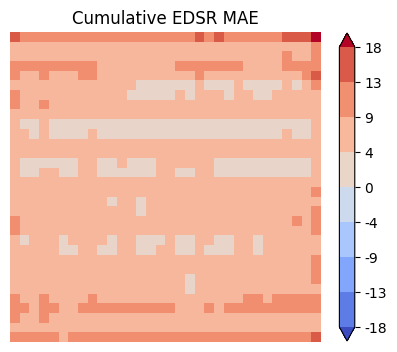

In [33]:
# cumulative mae over time plot
cumulative_mae = np.array(error_images["edsr"]).sum(axis=0)
min_val = cumulative_mae.min()
max_val = cumulative_mae.max()
max_val = max(abs(min_val), abs(max_val))
levels = np.linspace(-max_val, max_val, num=9)
cmap = plt.cm.coolwarm
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')

fig, ax = plt.subplots(1, 1, figsize=(5,5))
im = ax.imshow(cumulative_mae, cmap=cmap, norm=norm)
ax.set_title('Cumulative EDSR MAE')
ax.axis('off')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.set_yticklabels([f'{lvl:.0f}' for lvl in levels])

plt.show()


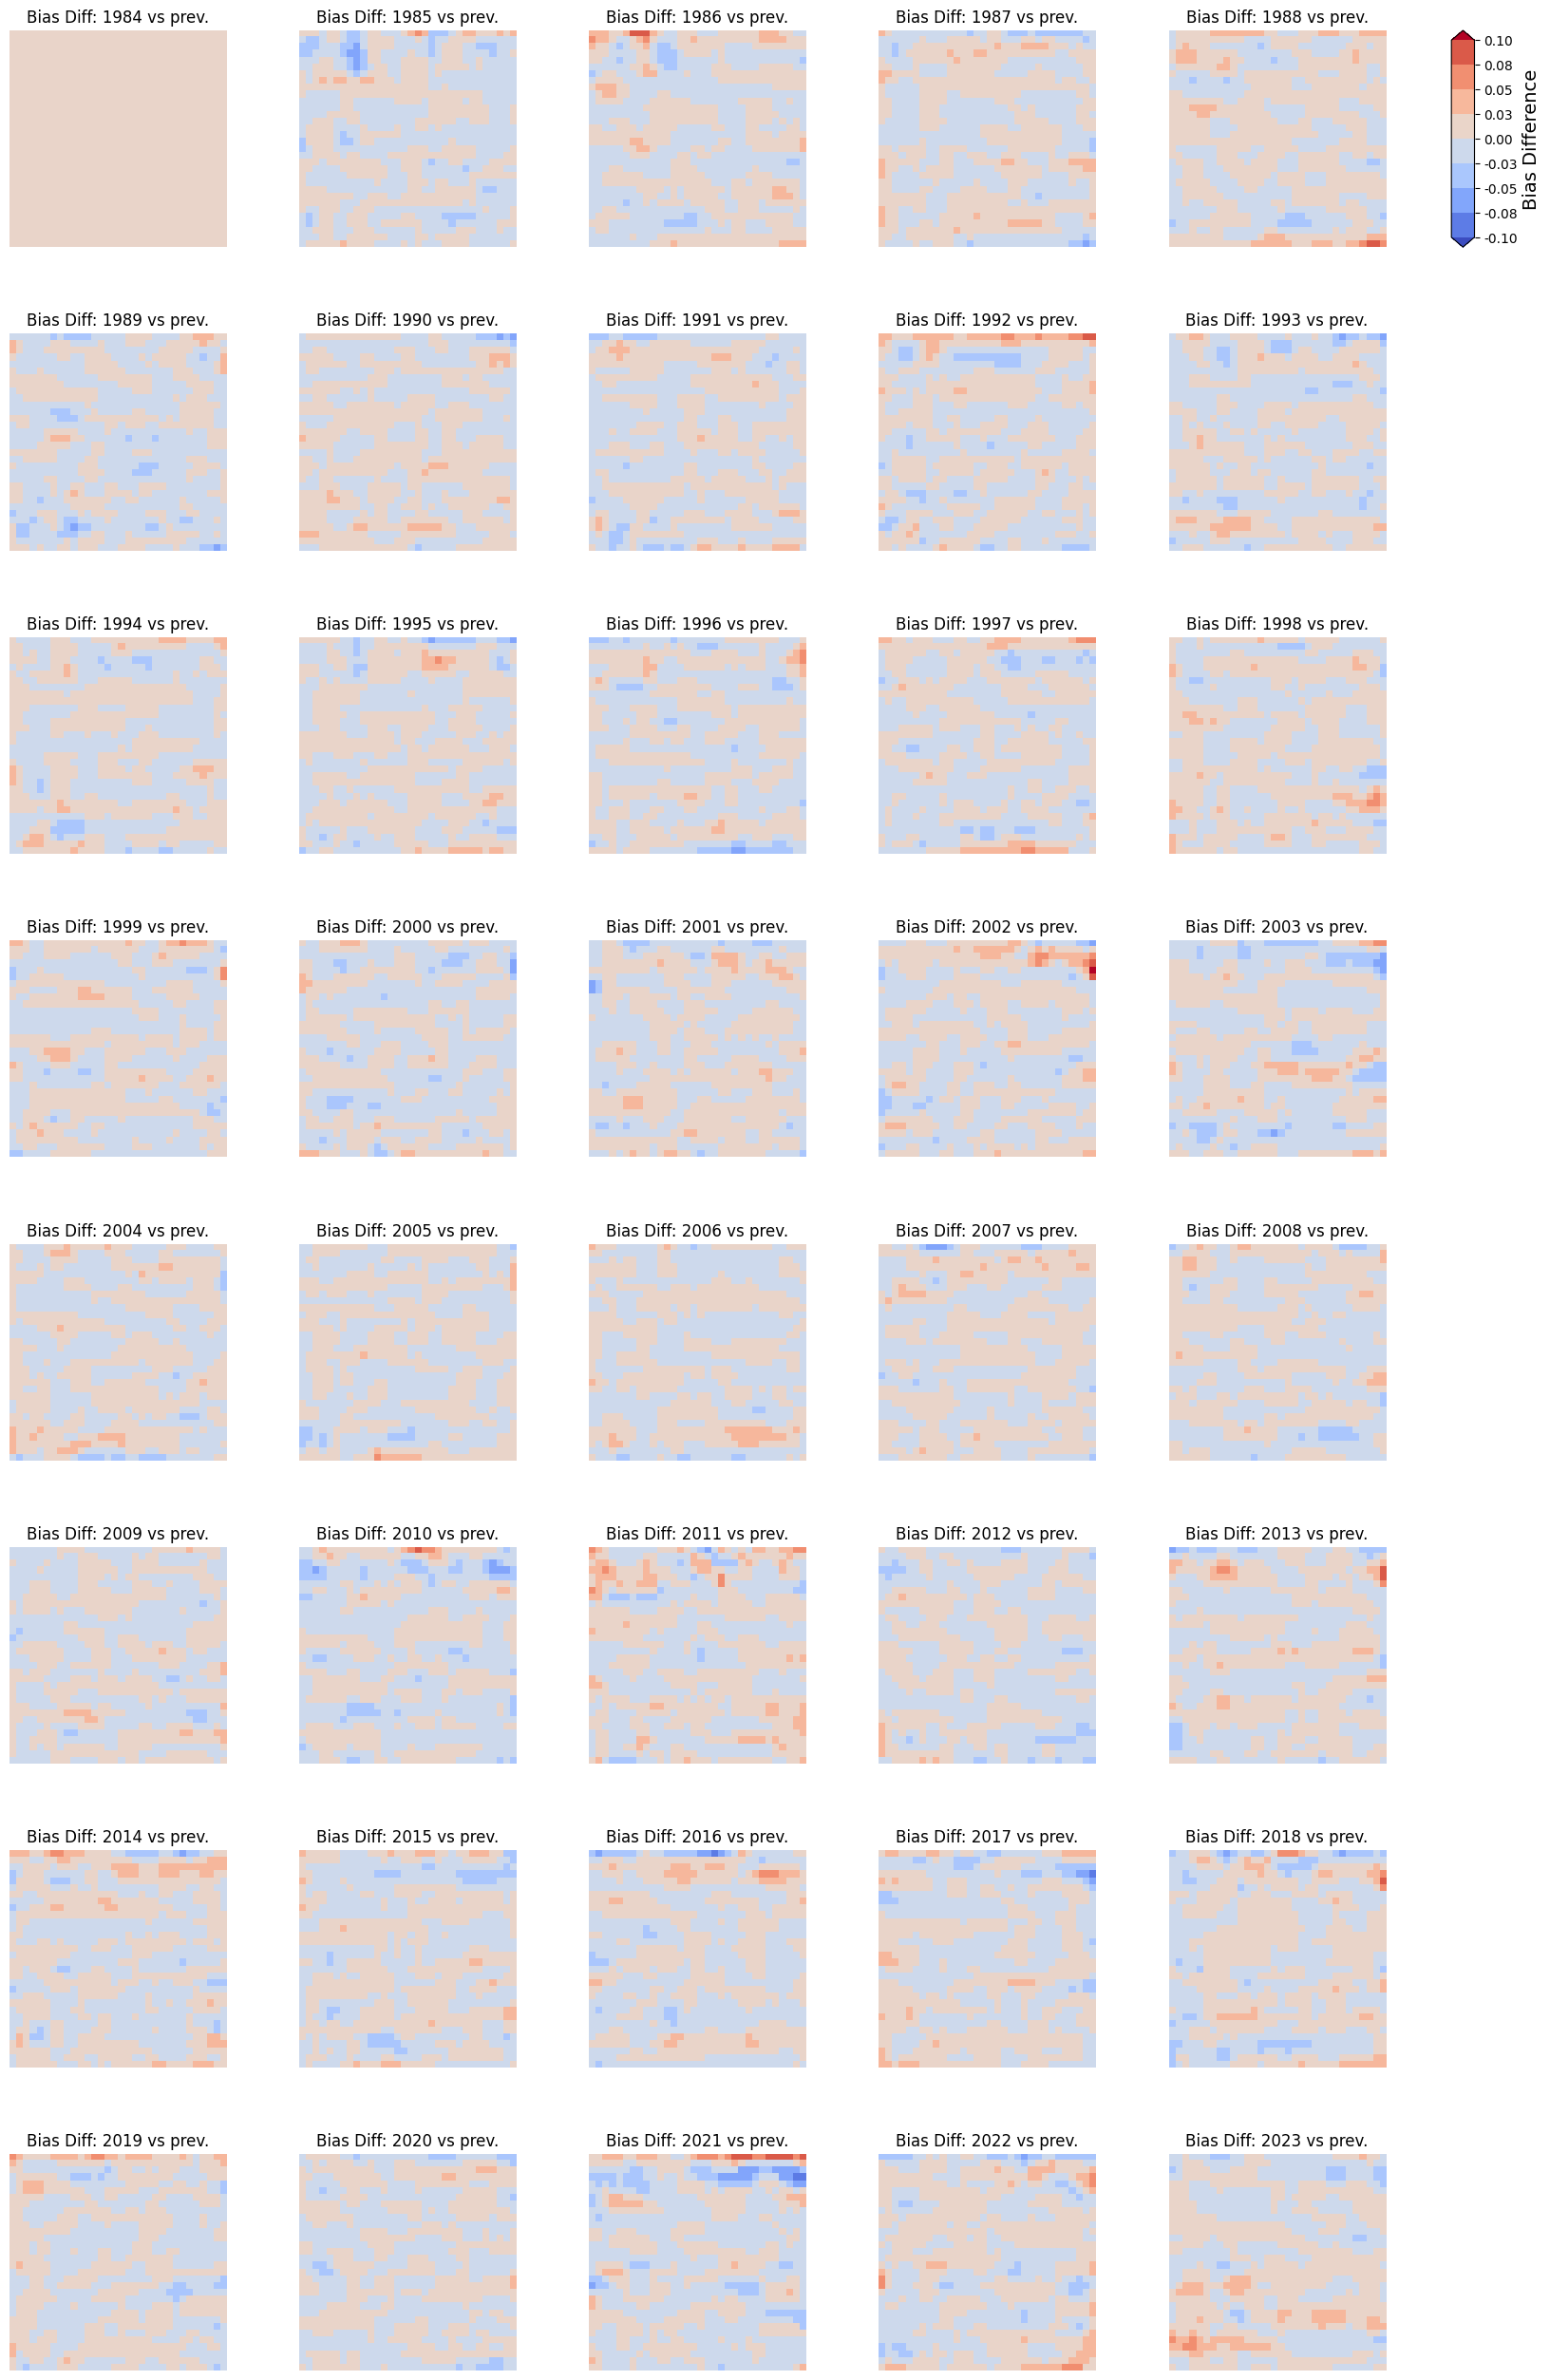

In [34]:
diff_biases = [error_images['edsr_bias'][i + 1] - error_images['edsr_bias'][i] for i in range(len(years)-1)]
diff_biases.insert(0, np.zeros_like(diff_biases[0]))

max_diff = max([np.abs(diff).max() for diff in diff_biases])
levels = np.linspace(-max_diff, max_diff, num=9)
cmap = plt.cm.coolwarm
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, extend='both')


ncols = 5
nrows = int(np.ceil(num_years / ncols))

fig = plt.figure(figsize=(4 * ncols, 4 * nrows))  
gs = fig.add_gridspec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.1], wspace=0.3, hspace=0.4)

axes = []
for i in range(8):
    for j in range(5):
        idx = i * 5 + j
        ax = fig.add_subplot(gs[i, j])
        if idx < len(diff_biases):
            im = ax.imshow(diff_biases[idx], cmap=cmap, norm=norm)
            ax.set_title(f'Bias Diff: {years[idx]} vs prev.', fontsize=12)
        else:
            ax.axis('off')
        ax.axis('off')
        axes.append(ax)

# Add colorbar only to the first row of the last column
n_rows = len(axes) // 5
cbar_ax = fig.add_subplot(gs[0, -1])  # Spanning all rows in the last column
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', ticks=levels, shrink=0.8, aspect=20)
cbar.set_label('Bias Difference', fontsize=14)
cbar.ax.set_yticklabels([f'{lvl:.2f}' for lvl in levels])

#
# plt.tight_layout()
plt.show()



# Bias over time

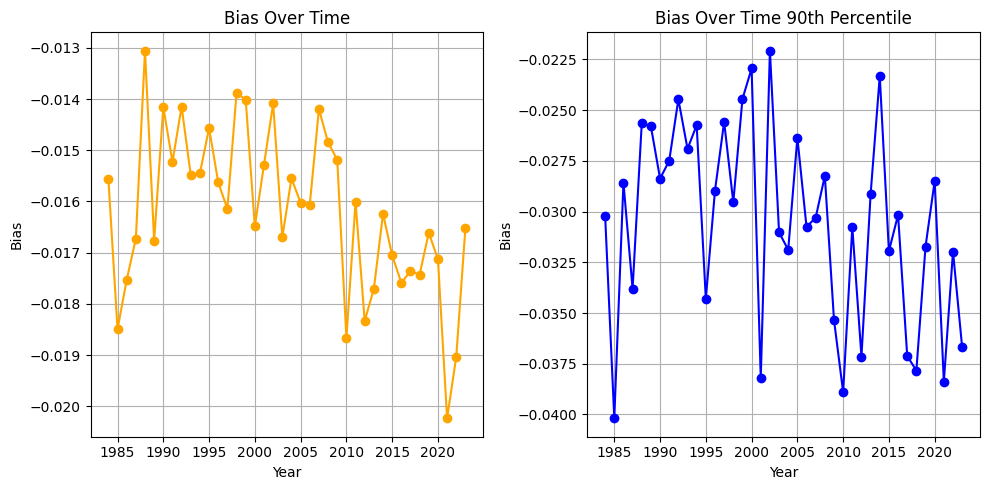

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(years, bias_per_year["edsr"], 'o-', label='EDSR', color='orange')
#ax[0].plot(years, bias_per_year["bicubic"], 'o-', label='Bicubic ', color='blue')
ax[0].set_title('Bias Over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Bias')
ax[0].grid(True)

#ax[1].plot(years, bias_per_year["bicubic_90th"], 'o-', label='Bicubic 90th', color='orange')
ax[1].plot(years, bias_per_year["edsr_90th"], 'o-', label='EDSR 90th ', color='blue')
ax[1].set_title('Bias Over Time 90th Percentile')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Bias')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Error over Time for one low res Pixel


In [36]:
lr_grid_size = 32 // SCALING_FACTOR  
n_lr_pixels = lr_grid_size ** 2

mse_per_pixel = {i: [] for i in range(n_lr_pixels)}
mae_per_pixel = {i: [] for i in range(n_lr_pixels)}

for i in range(n_lr_pixels):
    row, col = divmod(i, lr_grid_size) 
    for year in years:
        one_px_gt = ws_dict[year]['Ground Truth'][
            :, 
            row * SCALING_FACTOR : (row + 1) * SCALING_FACTOR,
            col * SCALING_FACTOR : (col + 1) * SCALING_FACTOR
        ]
        one_px_edsr = ws_dict[year]['EDSR'][
            :, 
            row * SCALING_FACTOR : (row + 1) * SCALING_FACTOR,
            col * SCALING_FACTOR : (col + 1) * SCALING_FACTOR
        ]
        
        one_pixel_mse, one_pixel_mae = get_metrics(one_px_edsr, one_px_gt)
        
        mse_per_pixel[i].append(one_pixel_mse)
        mae_per_pixel[i].append(one_pixel_mae)

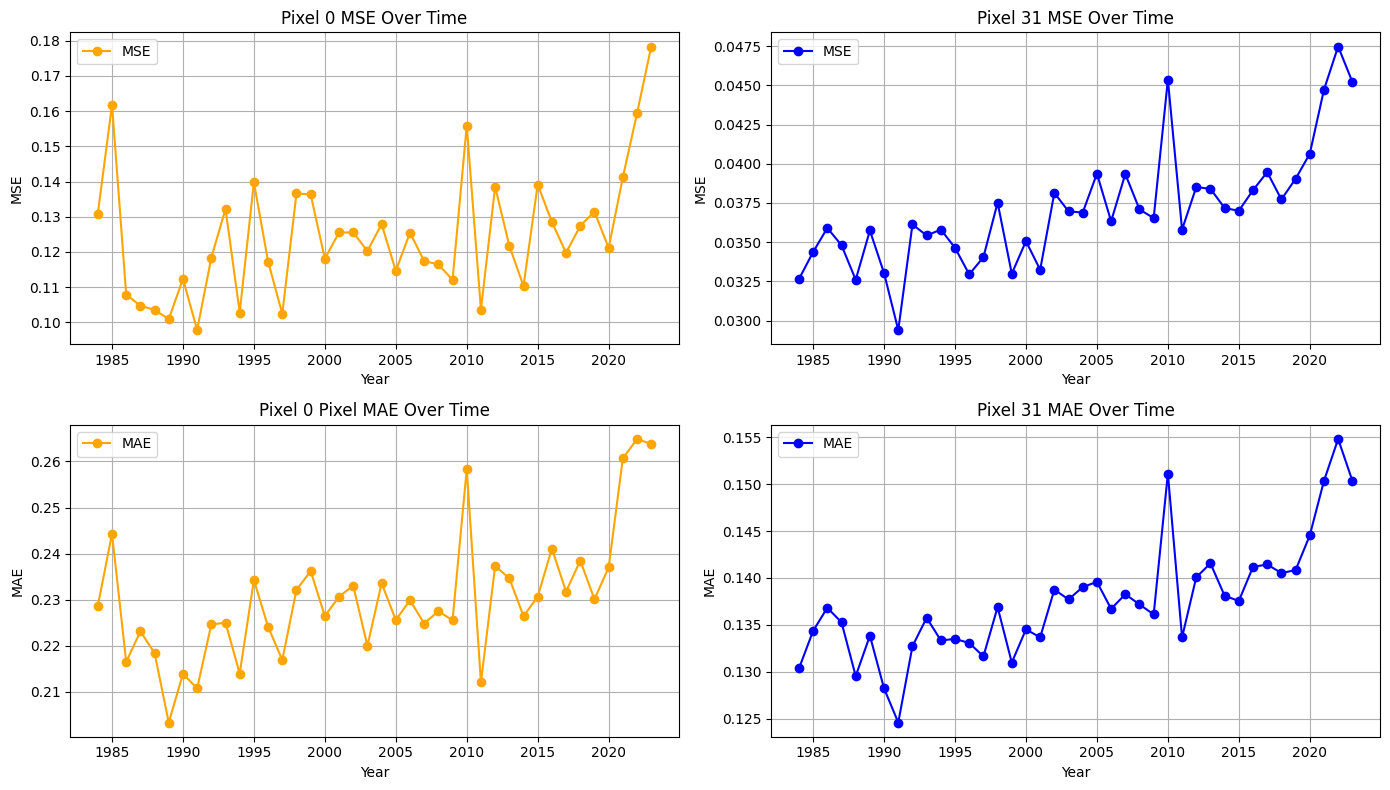

In [37]:
# plot first and last pixel error over time
first_pixel, second_pixel = 0, 63//2
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0, 0].plot(years, mse_per_pixel[first_pixel], 'o-', label='MSE', color='orange')
ax[0, 0].set_title(f'Pixel {list(mse_per_pixel.keys())[first_pixel]} MSE Over Time')
ax[0, 0].set_xlabel('Year')
ax[0, 0].set_ylabel('MSE')
ax[0, 0].legend() 
ax[0, 0].grid(True)

ax[0, 1].plot(years, mse_per_pixel[second_pixel], 'o-', label='MSE', color='blue')
ax[0, 1].set_title(f'Pixel {list(mse_per_pixel.keys())[second_pixel]} MSE Over Time')
ax[0, 1].set_xlabel('Year')
ax[0, 1].set_ylabel('MSE')
ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].plot(years, mae_per_pixel[first_pixel], 'o-', label='MAE', color='orange')
ax[1, 0].set_title(f'Pixel {list(mse_per_pixel.keys())[first_pixel]} Pixel MAE Over Time')
ax[1, 0].set_xlabel('Year')
ax[1, 0].set_ylabel('MAE')
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[1, 1].plot(years, mae_per_pixel[second_pixel], 'o-', label='MAE', color='blue')
ax[1, 1].set_title(f"Pixel {list(mse_per_pixel.keys())[second_pixel]} MAE Over Time")
ax[1, 1].set_xlabel('Year')
ax[1, 1].set_ylabel('MAE')
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()



# Correlation of Mean Wind Speed and Model Error


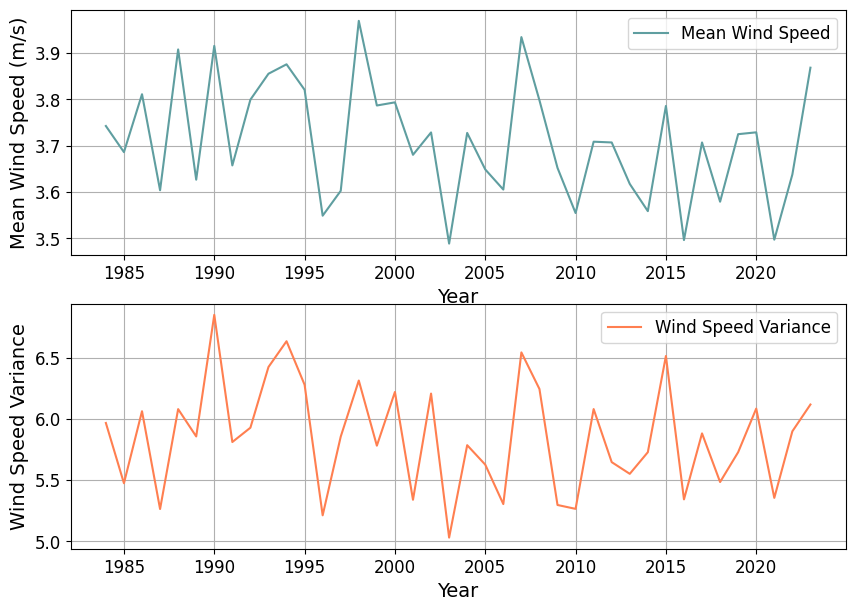

In [38]:

fig, ax = plt.subplots(2,1, figsize=(10,7))

# Plot Mean Wind Speed with Standard Deviation Range
gt_stats['mean'] = np.array(gt_stats['mean'])
gt_stats['var'] = np.array(gt_stats['var'])
gt_stats['std'] = np.array(gt_stats['std'])
ax[0].plot(years, gt_stats['mean'], label='Mean Wind Speed', color='cadetblue')
"""
ax[0].fill_between(
    years,
    gt_stats['mean'] - gt_stats['std'],  
    gt_stats['mean'] + gt_stats['std'], 
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
)
"""
ax[0].set_xlabel('Year', fontsize=14)
ax[0].set_ylabel('Mean Wind Speed (m/s)', fontsize=14)
ax[0].legend(fontsize=12)
ax[0].grid(True)

# Plot Wind Speed Variance Over Time
ax[1].plot(years, gt_stats['var'], label='Wind Speed Variance', color='coral')
ax[1].set_xlabel('Year', fontsize=14)
ax[1].set_ylabel('Wind Speed Variance', fontsize=14)
ax[1].legend(fontsize=12)
ax[1].grid(True)

for a in ax:
    a.tick_params(axis='both', labelsize=12)
plt.savefig(f'../../plots/gt_stats.pdf', bbox_inches='tight')
plt.show()


Mean
Linear Regression Slope: -0.003264
Linear Regression Intercept: 10.250906
Linear Regression R-value: -0.301097
Linear Regression P-value: 0.059026
Linear Regression Std. Error: 0.001677

Variance
Linear Regression Slope: -0.006449
Linear Regression Intercept: 18.771508
Linear Regression R-value: -0.170594
Linear Regression P-value: 0.292588
Linear Regression Std. Error: 0.006042


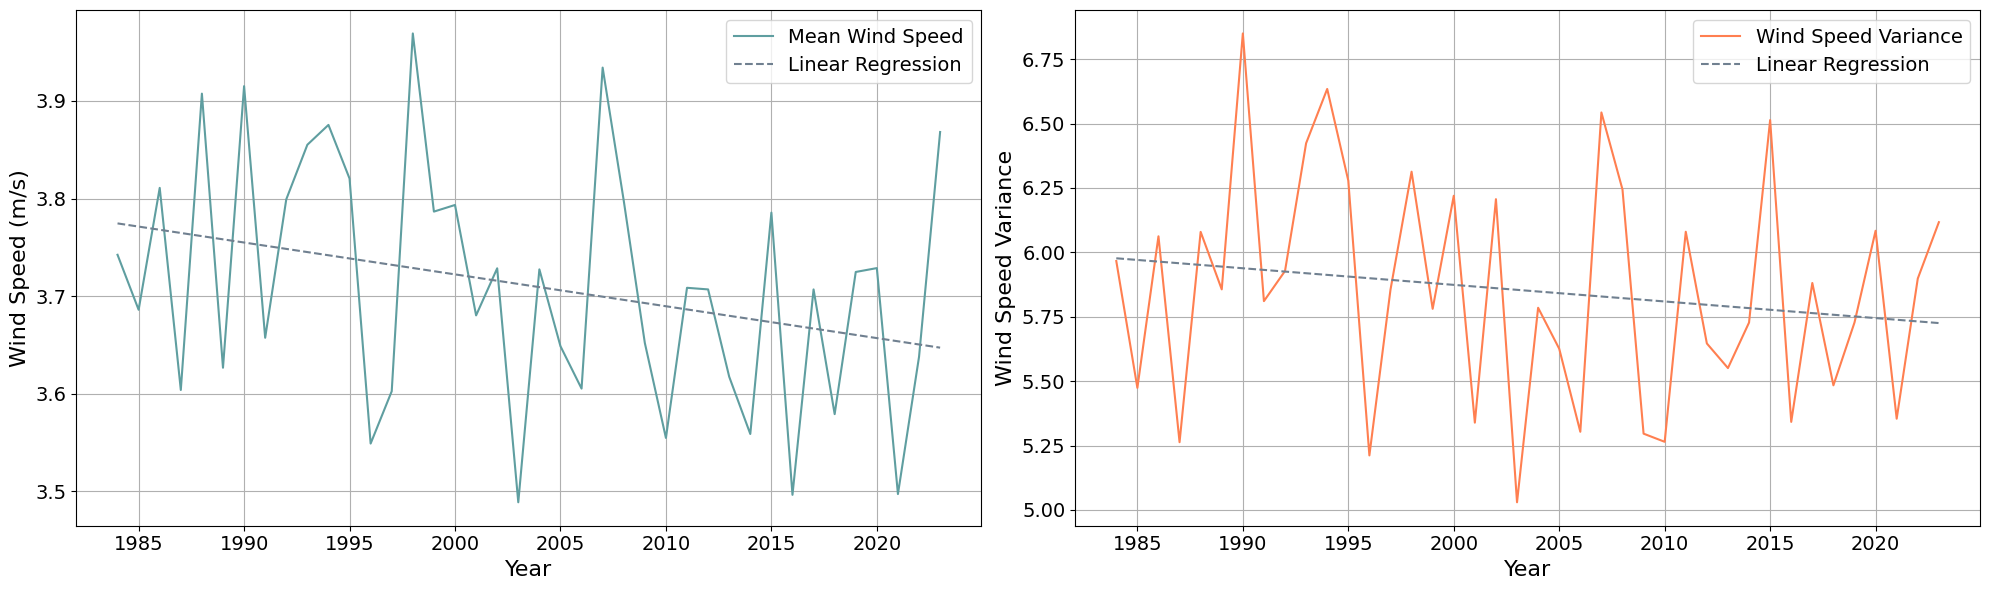

In [39]:
linreg_mean = linregress(years, gt_stats['mean'])
print("Mean")
print(f"Linear Regression Slope: {linreg_mean.slope:.6f}")
print(f"Linear Regression Intercept: {linreg_mean.intercept:.6f}")
print(f"Linear Regression R-value: {linreg_mean.rvalue:.6f}")
print(f"Linear Regression P-value: {linreg_mean.pvalue:.6f}")
print(f"Linear Regression Std. Error: {linreg_mean.stderr:.6f}")

linreg_var = linregress(years, gt_stats['var'])
print("\nVariance")
print(f"Linear Regression Slope: {linreg_var.slope:.6f}")
print(f"Linear Regression Intercept: {linreg_var.intercept:.6f}")
print(f"Linear Regression R-value: {linreg_var.rvalue:.6f}")
print(f"Linear Regression P-value: {linreg_var.pvalue:.6f}")
print(f"Linear Regression Std. Error: {linreg_var.stderr:.6f}")

fig, ax = plt.subplots(1, 2, figsize=(20, 6))
ax[0].plot(years, gt_stats['mean'], label='Mean Wind Speed', color='cadetblue')
ax[0].plot(years,linreg_mean.slope * np.array(years) + linreg_mean.intercept, "--", label='Linear Regression', color='slategrey')
ax[0].set_xlabel('Year', fontsize=XYFONTSIZE)
ax[0].set_ylabel('Wind Speed (m/s)', fontsize=XYFONTSIZE)
ax[0].legend(fontsize=LEGEND_TICK_FONTSIZE)
ax[0].grid(True)
ax[1].plot(years, gt_stats['var'], label='Wind Speed Variance', color='coral')
ax[1].plot(years, np.array(years) * linreg_var.slope + linreg_var.intercept, "--",label='Linear Regression',  color='slategrey')
ax[1].set_xlabel('Year', fontsize=XYFONTSIZE)
ax[1].set_ylabel('Wind Speed Variance', fontsize=XYFONTSIZE)
ax[1].legend(fontsize=LEGEND_TICK_FONTSIZE)
ax[1].grid(True)
for a in ax:
    a.tick_params(axis='both', labelsize=LEGEND_TICK_FONTSIZE)
plt.tight_layout()
plt.show()



In [40]:
mse_corr, p_mse = pearsonr(gt_stats['mean'], mses['EDSR'])
mae_corr, p_mae = pearsonr(gt_stats['mean'], maes['EDSR'])
mse_corr_baseline, p_mse_baseline = pearsonr(gt_stats['mean'], mses['Bicubic'])
mae_corr_baseline, p_mae_baseline= pearsonr(gt_stats['mean'], maes['Bicubic'])

print(f"Correlation between Mean Wind Speed and EDSR MSE: {mse_corr:.4f} with p-value: {p_mse:.4f}")
print(f"Correlation between Mean Wind Speed and EDSR MAE: {mae_corr:.4f} with p-value: {p_mae:.4f}")
print(f"Correlation between Mean Wind Speed and Bicubic MSE: {mse_corr_baseline:.4f} with p-value: {p_mse_baseline:.4f}")
print(f"Correlation between Mean Wind Speed and Bicubic MAE: {mae_corr_baseline:.4f} with p-value: {p_mae_baseline:.4f}")


Correlation between Mean Wind Speed and EDSR MSE: -0.2829 with p-value: 0.0769
Correlation between Mean Wind Speed and EDSR MAE: -0.4069 with p-value: 0.0092
Correlation between Mean Wind Speed and Bicubic MSE: 0.5636 with p-value: 0.0002
Correlation between Mean Wind Speed and Bicubic MAE: 0.3849 with p-value: 0.0142


In [41]:
mse_corr, p_mse = pearsonr(gt_stats['var'], mses['EDSR'])
mae_corr, p_mae = pearsonr(gt_stats['var'], maes['EDSR'])
mse_corr_baseline, p_mse_baseline = pearsonr(gt_stats['var'], mses['Bicubic'])
mae_corr_baseline, p_mae_baseline= pearsonr(gt_stats['var'], maes['Bicubic'])

print(f"Correlation between Wind Speed Variance and EDSR MSE: {mse_corr:.4f} with p-value: {p_mse:.4f}")
print(f"Correlation between Wind Speed Variance and EDSR MAE: {mae_corr:.4f} with p-value: {p_mae:.4f}")
print(f"Correlation between Wind Speed Variance and Bicubic MSE: {mse_corr_baseline:.4f} with p-value: {p_mse_baseline:.4f}")
print(f"Correlation between Wind Speed Variance and Bicubic MAE: {mae_corr_baseline:.4f} with p-value: {p_mae_baseline:.4f}")

Correlation between Wind Speed Variance and EDSR MSE: -0.1816 with p-value: 0.2622
Correlation between Wind Speed Variance and EDSR MAE: -0.3004 with p-value: 0.0596
Correlation between Wind Speed Variance and Bicubic MSE: 0.4795 with p-value: 0.0017
Correlation between Wind Speed Variance and Bicubic MAE: 0.3588 with p-value: 0.0230


# Fitting Exponentiated Weibull Distributitions to predicted wind speed, 

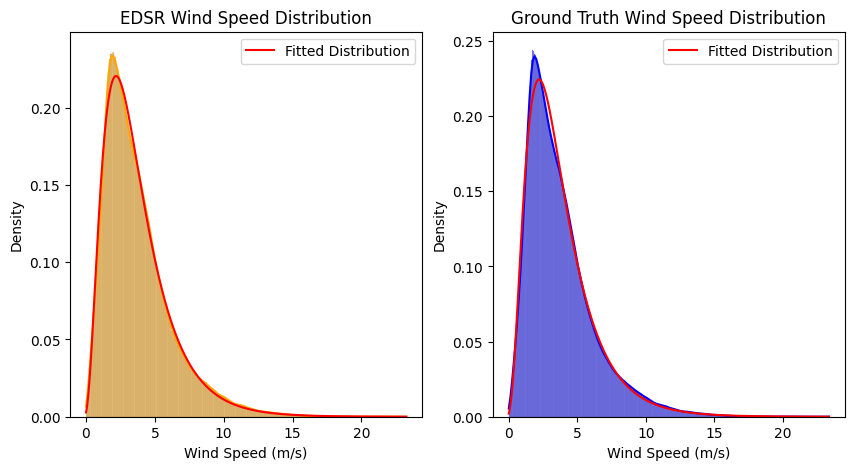

In [42]:
#fit exponentiated weibull to ws_dict[1984]['EDSR'] and ws_dict[1984]['Ground Truth']

min_gt = ws_dict[1984]['Ground Truth'].min()
max_gt = ws_dict[1984]['Ground Truth'].max()
x_gt = np.linspace(min_gt, max_gt, 1000)

min_edsr = ws_dict[1984]['EDSR'].min()
max_edsr = ws_dict[1984]['EDSR'].max()
x_edsr = np.linspace(min_edsr, max_edsr, 1000)

a1, c1, loc1, scale1 = exponweib.fit(ws_dict[1984]['EDSR'])
a2, c2, loc2, scale2 = exponweib.fit(ws_dict[1984]['Ground Truth'])
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(ws_dict[1984]['EDSR'].flatten(), kde=True, ax=ax[0], color='orange', stat='density')
sns.histplot(ws_dict[1984]['Ground Truth'].flatten(), kde=True, ax=ax[1], color='blue',stat='density')

pdf_edsr = exponweib.pdf(x_edsr, a1, c1, loc=loc1, scale=scale1)
pdf_gt = exponweib.pdf(x_gt, a2, c2, loc=loc2, scale=scale2)
ax[0].plot(x_edsr, pdf_edsr, color='red', label='Fitted Distribution')
ax[1].plot(x_gt, pdf_gt, color='red', label='Fitted Distribution')
ax[0].set_title('EDSR Wind Speed Distribution')
ax[0].set_xlabel('Wind Speed (m/s)')
ax[0].set_ylabel('Density')
ax[0].legend()

ax[1].set_title('Ground Truth Wind Speed Distribution')
ax[1].set_xlabel('Wind Speed (m/s)')
ax[1].set_ylabel('Density')
ax[1].legend()



In [43]:
years2 = list(range(1984, 2024,  5))
years2.append(2023)
#years2 = years
print(years2)



[1984, 1989, 1994, 1999, 2004, 2009, 2014, 2019, 2023]


In [44]:

params_gt = {year : exponweib.fit(ws_dict[year]['Ground Truth']) for year in years}
params_edsr = {year : exponweib.fit(ws_dict[year]['EDSR']) for year in years}


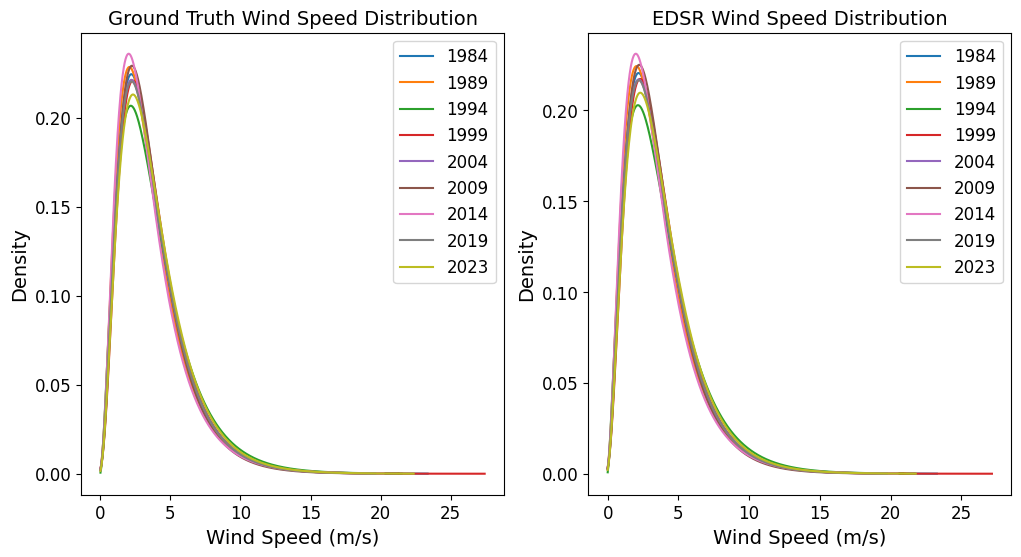

In [53]:
# plot pdfs for each year
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
colors = sns.color_palette('tab10', len(years2))
for i,year in enumerate(years2):
    x_gt = np.linspace(ws_dict[year]['Ground Truth'].min(), ws_dict[year]['Ground Truth'].max(), 1000)
    x_edsr = np.linspace(ws_dict[year]['EDSR'].min(), ws_dict[year]['EDSR'].max(), 1000)
    pdf_gt = exponweib.pdf(x_gt, *params_gt[year])
    pdf_edsr = exponweib.pdf(x_edsr, *params_edsr[year])
    ax[0].plot(x_gt, pdf_gt, label=f'{year}' ,color=colors[i])
    ax[1].plot(x_edsr, pdf_edsr, label=f'{year}', color=colors[i])
    
ax[0].set_title('Ground Truth Wind Speed Distribution', fontsize=14)
ax[0].set_xlabel('Wind Speed (m/s)', fontsize=14)
ax[0].set_ylabel('Density', fontsize=14)
ax[0].legend(fontsize=12)
ax[1].set_title('EDSR Wind Speed Distribution', fontsize=14)
ax[1].set_xlabel('Wind Speed (m/s)', fontsize=14)
ax[1].set_ylabel('Density', fontsize=14)
ax[1].legend(fontsize=12)

for a in ax:
    a.tick_params(axis='both', labelsize=12)
plt.savefig(f'../../plots/pdf_fits.pdf', bbox_inches='tight')
plt.show()


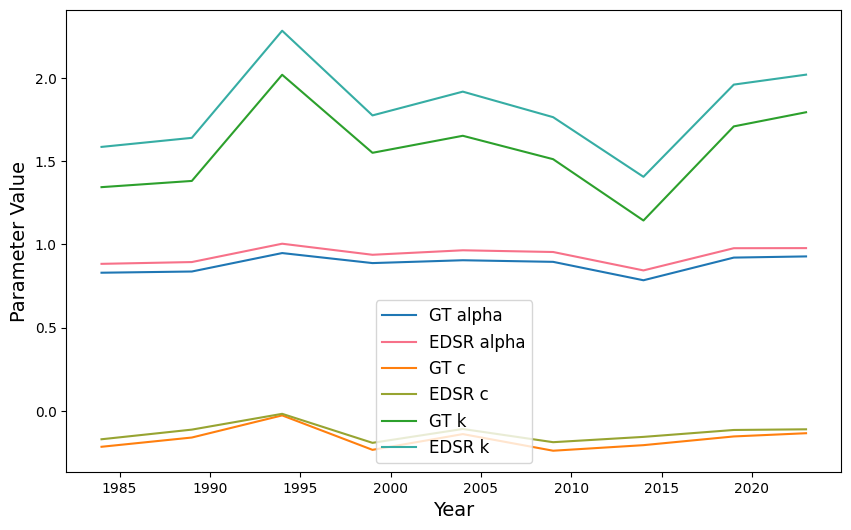

In [52]:
params_gt_array = np.array(list(params_gt.values()))  
params_edsr_array = np.array(list(params_edsr.values()))  
# get only the params that are for years2
params_gt_array = params_gt_array[[years.index(year) for year in years2]]
params_edsr_array = params_edsr_array[[years.index(year) for year in years2]]
#ignore locaiton parameter
params_gt_array = params_gt_array[:, 1:]
params_edsr_array = params_edsr_array[:, 1:]
fig, ax = plt.subplots(figsize=(10, 6))
colors_gt = sns.color_palette('tab10', 4)
colors_edsr = sns.color_palette('husl', 4)
labels = ['alpha', 'c',  'k']
for i in range(3):
    ax.plot(years2, params_gt_array[:, i], label=f'GT {labels[i]}', color=colors_gt[i])
    ax.plot(years2, params_edsr_array[:, i], label=f'EDSR {labels[i]}', color=colors_edsr[i])

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Parameter Value', fontsize=14)

ax.legend(fontsize=12)

plt.savefig(f'../../plots/parameter_fits.pdf', bbox_inches='tight')
plt.show()

In [47]:
params_gt_dict = {year: {'a': params_gt[year][0], 'c': params_gt[year][1], 'loc': params_gt[year][2], 'scale': params_gt[year][3]} for year in years2}
params_edsr_dict = {year: {'a': params_edsr[year][0], 'c': params_edsr[year][1], 'loc': params_edsr[year][2], 'scale': params_edsr[year][3]} for year in years2}

avg_c = np.mean(params_edsr_array[:, 1])
avg_loc = np.mean(params_gt_array[:, 2])
avg_scale = np.mean(params_gt_array[:, 3])

fit_with_fixed_c = {year: exponweib.fit(ws_dict[year]['EDSR'], f1=avg_c) for year in years2}
fit_with_fixed_c = np.array(list(fit_with_fixed_c.values()))


IndexError: index 3 is out of bounds for axis 1 with size 3

In [ ]:
avg_c_gt = np.mean(params_gt_array[:, 1])

fit_with_fixed_c_gt = {year: exponweib.fit(ws_dict[year]['Ground Truth'], f1=avg_c_gt) for year in years2}
fit_with_fixed_c_gt = np.array(list(fit_with_fixed_c_gt.values()))

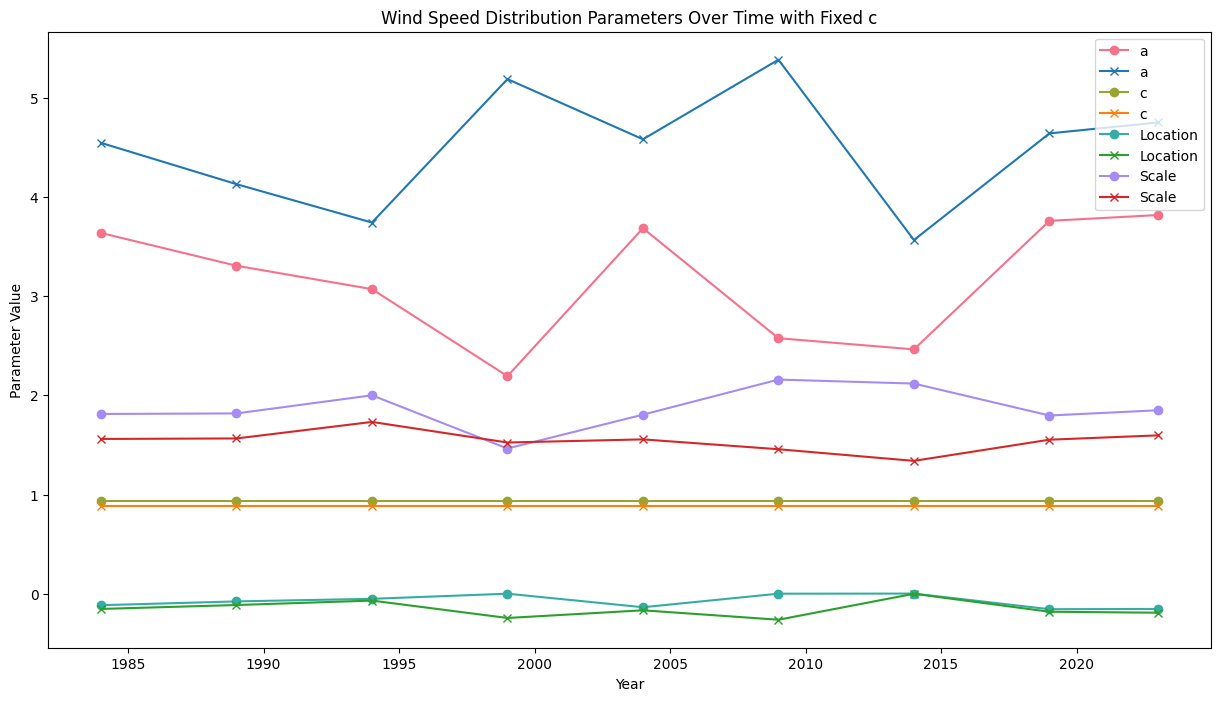

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))
for i in range(4):
    ax.plot(years2, fit_with_fixed_c[:, i], label=f'{labels[i]}', color=colors_edsr[i], marker='o')
    ax.plot(years2, fit_with_fixed_c_gt[:, i], label=f'{labels[i]}', color=colors_gt[i], marker='x')
ax.set_title('Wind Speed Distribution Parameters Over Time with Fixed c')
ax.set_xlabel('Year')
ax.set_ylabel('Parameter Value')
ax.legend()

In [ ]:
from scipy.stats import goodness_of_fit


x = np.linspace(ws_dict[2023]['EDSR'].min(), ws_dict[2023]['EDSR'].max(), 1000)
res = goodness_of_fit(dist = exponweib,
                             data = x,
                             fit_params = params_edsr_dict[2023],
                             statistic='ks',
                             n_mc_samples=1000,
                             )


In [ ]:
print(res)

GoodnessOfFitResult(fit_result=  params: FitParams(a=np.float64(3.338874921255859), c=np.float64(0.977427979406145), loc=np.float64(-0.11042356902402978), scale=np.float64(2.0188578044094734))
 success: True
 message: 'The fit was performed successfully.', statistic=np.float64(0.01956891522291937), pvalue=np.float64(0.3276723276723277), null_distribution=array([0.02336608, 0.02097053, 0.01688286, 0.01820715, 0.01443555,
       0.01792636, 0.01572262, 0.02232855, 0.02415621, 0.02558363,
       0.02459649, 0.01469165, 0.02222244, 0.01257535, 0.01319086,
       0.02082247, 0.01846899, 0.01196215, 0.02170996, 0.02094327,
       0.0174183 , 0.01250289, 0.02285162, 0.02445654, 0.01804874,
       0.01723698, 0.02501029, 0.01627407, 0.01701266, 0.02036629,
       0.02705145, 0.01336262, 0.01463483, 0.01909273, 0.02611416,
       0.01263857, 0.01307871, 0.01862633, 0.0236839 , 0.01110008,
       0.01946436, 0.01825628, 0.02398284, 0.01533817, 0.01834729,
       0.01398951, 0.02023539, 0.0158215

# Regression on model error over time

## Linear regression

### MSE

In [ ]:
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress


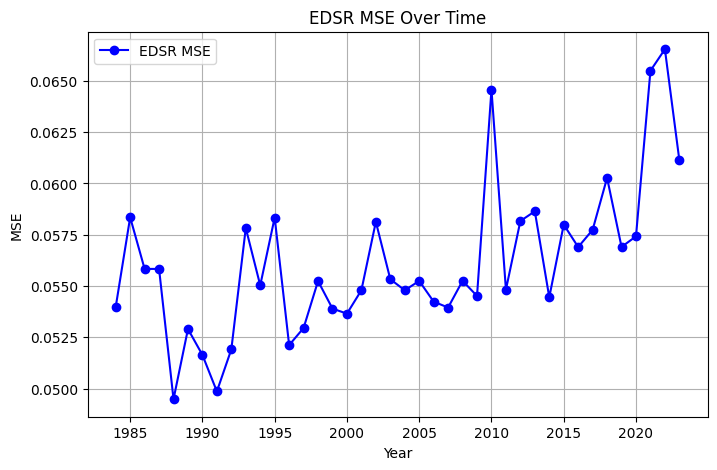

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

Slope: 0.0002, 
Intercept: -0.3345, 
R-value: 0.6108, 
P-value: 0.00002845, 
Std. Error: 0.0000


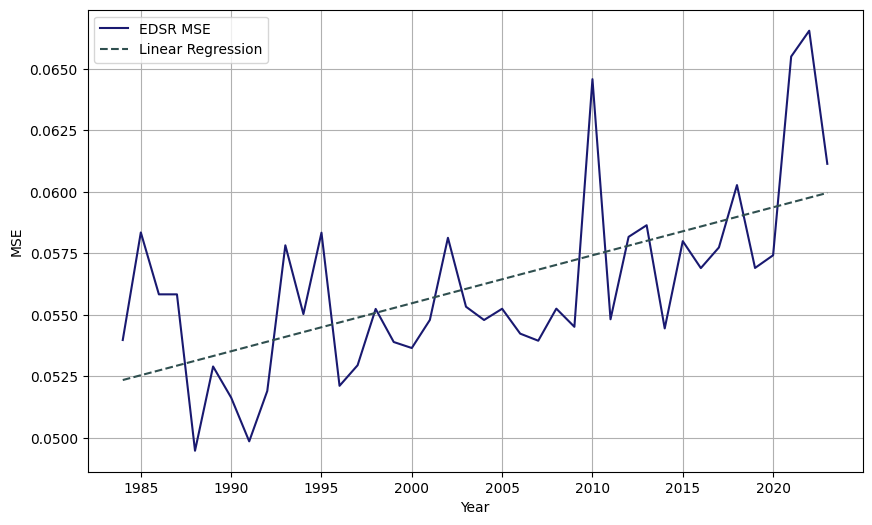

In [ ]:
res = linregress(years, mses['EDSR'])
slope, intercept, r_value, p_value, std_err = res
print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(years, mses['EDSR'], label='EDSR MSE', color='midnightblue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='darkslategray')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()


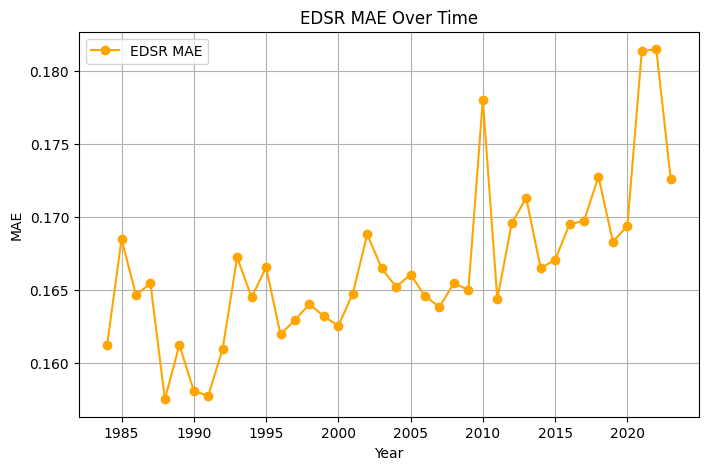

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='orange')
#ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

Slope: 0.0003, 
Intercept: -0.4885, 
R-value: 0.7067, 
P-value: 0.00000035, 
Std. Error: 0.0001


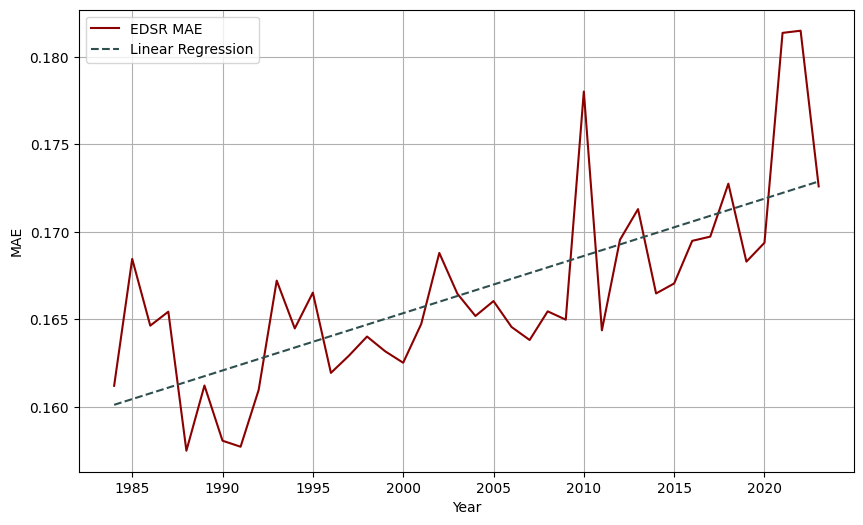

In [ ]:
res = linregress(years, maes['EDSR'])
slope, intercept, r_value, p_value, std_err = res
print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(years, maes['EDSR'], label='EDSR MAE', color='darkred')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='darkslategray')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

# Regression without 2020s



Slope: 0.0001, 
Intercept: -0.2052, 
R-value: 0.4830, 
P-value: 0.00246146, 
Std. Error: 0.0000


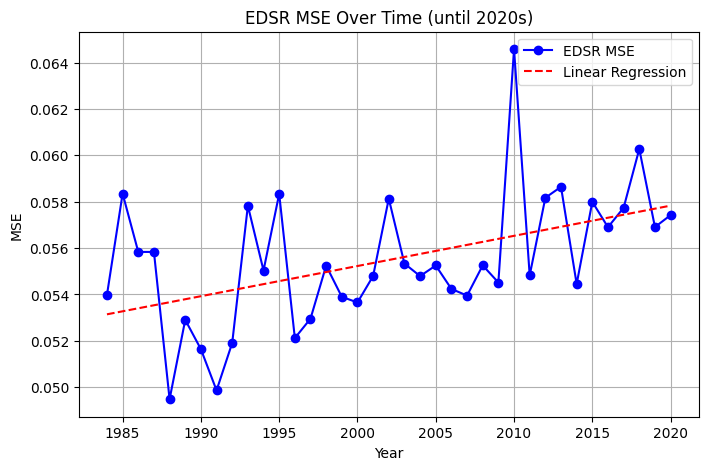

Slope: 0.0002, 
Intercept: -0.3246, 
R-value: 0.6368, 
P-value: 0.00002263, 
Std. Error: 0.0001


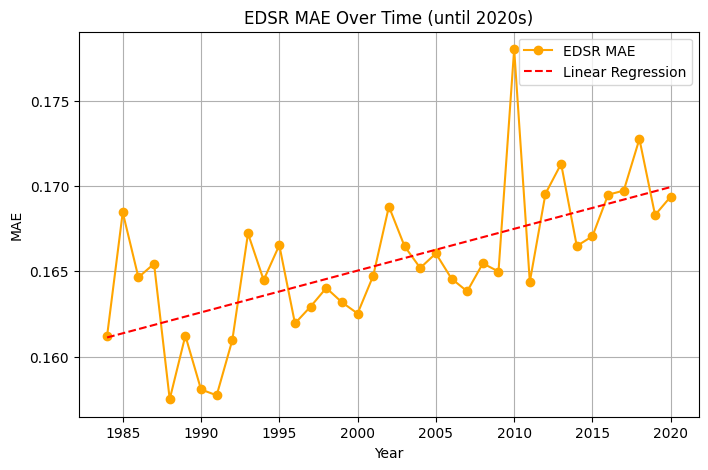

In [ ]:
years_no_2020s = years[:-3]
mses_no_2020s = mses['EDSR'][:-3]
maes_no_2020s = maes['EDSR'][:-3]

res = linregress(years_no_2020s, mses_no_2020s)
slope, intercept, r_value, p_value, std_err = res
print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years_no_2020s, mses_no_2020s, 'o-', label='EDSR MSE', color='blue')
ax.plot(years_no_2020s, slope * np.array(years_no_2020s) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time (until 2020s)')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')

ax.legend()
ax.grid(True)
plt.show()

res = linregress(years_no_2020s, maes_no_2020s)
slope, intercept, r_value, p_value, std_err = res
print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years_no_2020s, maes_no_2020s, 'o-', label='EDSR MAE', color='orange')
ax.plot(years_no_2020s, slope * np.array(years_no_2020s) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MAE Over Time (until 2020)')

ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()


### MAE

## Exp Regression


### MSE

Exponential Regression Coefficients: [ 1.63970785e-04 -6.53620626e-01  6.48444623e+02]
R² Score for Exponential Regression: 0.4747


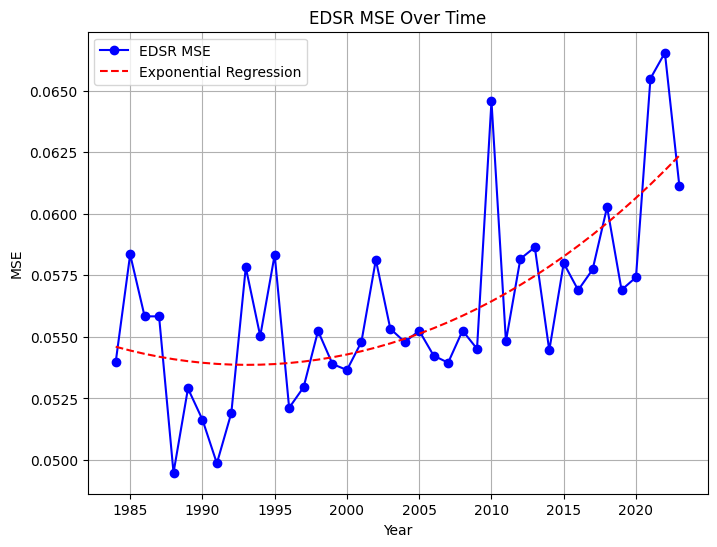

Predicted MSE for 2024: 0.0630


In [ ]:
mses['EDSR'] = np.array(mses['EDSR'])
fit = np.polyfit(years, np.log(mses['EDSR']), 2)
print(f"Exponential Regression Coefficients: {fit}")
predicted_mse = np.exp(np.polyval(fit, years))
# get residual error
r_squared = 1 - (np.sum((predicted_mse - mses['EDSR'])**2) / np.sum((mses['EDSR'] - mses['EDSR'].mean())**2))

print(f"R² Score for Exponential Regression: {r_squared:.4f}")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, predicted_mse, '--', label='Exponential Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

#now predict for 2024
predicted_mse_2024 = np.exp(np.polyval(fit, [2024]))
print(f"Predicted MSE for 2024: {predicted_mse_2024[0]:.4f}")



### MAE

Exponential Regression Coefficients: [ 6.83573078e-05 -2.71961923e-01  2.68686295e+02]
R² Score for Exponential Regression: 0.5701


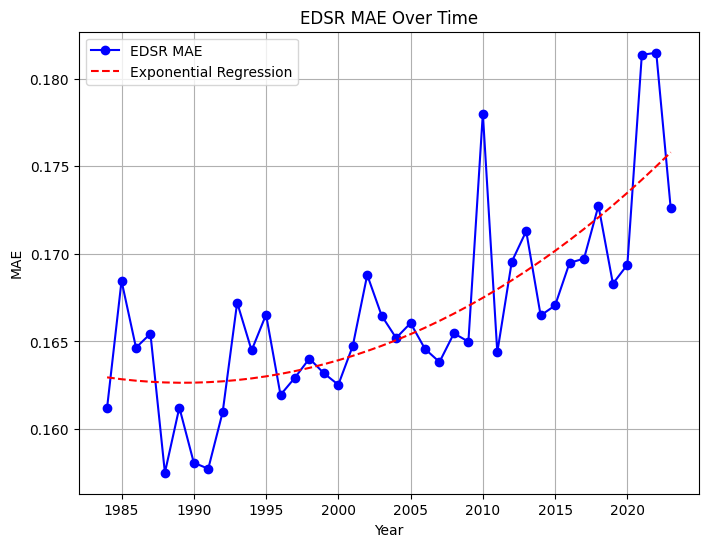

In [ ]:
maes['EDSR'] = np.array(maes['EDSR'])
fit = np.polyfit(years, np.log(maes['EDSR']), 2)
print(f"Exponential Regression Coefficients: {fit}")
predicted_mae = np.exp(np.polyval(fit, years))

ss_res = np.sum((maes['EDSR'] - predicted_mae) ** 2)
ss_tot = np.sum((maes['EDSR'] - np.mean(maes['EDSR'])) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² Score for Exponential Regression: {r_squared:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))    
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, predicted_mae, '--', label='Exponential Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()



# Log regression


## MSE

Logarithmic Regression Coefficients: [  39.53011247 -600.67427162 2281.91925402]
R² Score for Logarithmic Regression: 0.4733


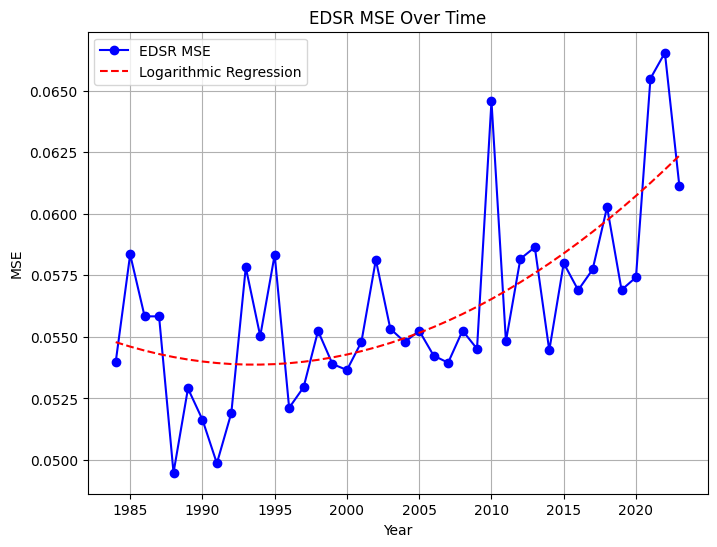

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


mses['EDSR'] = np.array(mses['EDSR'])

fit_log = np.polyfit(np.log(years), mses['EDSR'], 2)
print(f"Logarithmic Regression Coefficients: {fit_log}")

predicted_mse_log = np.polyval(fit_log, np.log(years))
r_squared_log = 1 - (np.sum((predicted_mse_log - mses['EDSR'])**2) / np.sum((mses['EDSR'] - mses['EDSR'].mean())**2))

print(f"R² Score for Logarithmic Regression: {r_squared_log:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, predicted_mse_log, '--', label='Logarithmic Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()



## MAE

Logarithmic Regression Coefficients: [  48.04021121 -729.80802074 2771.90187215]
R² Score for Logarithmic Regression: 0.5697


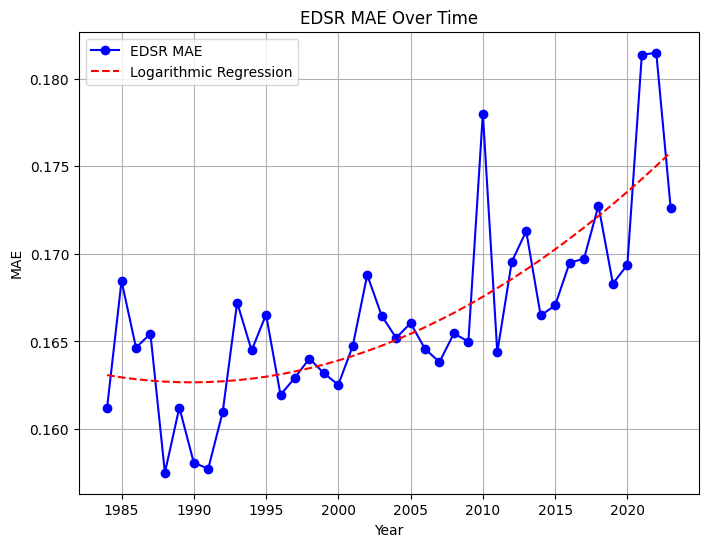

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


maes['EDSR'] = np.array(maes['EDSR'])

fit_log = np.polyfit(np.log(years), maes['EDSR'], 2)
print(f"Logarithmic Regression Coefficients: {fit_log}")

predicted_mae_log = np.polyval(fit_log, np.log(years))
r_squared_log = 1 - (np.sum((predicted_mae_log - maes['EDSR'])**2) / np.sum((maes['EDSR'] - maes['EDSR'].mean())**2))

print(f"R² Score for Logarithmic Regression: {r_squared_log:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, predicted_mae_log, '--', label='Logarithmic Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

